# Laboratorio 4 – Árboles de Decisión
**CC3074 – Minería de Datos | Universidad del Valle de Guatemala | Semestre I 2026**

**Contexto:** SmartStay Advisors necesita modelos para estimar precios de propiedades Airbnb, identificar propiedades con baja ocupación y comprender qué factores influyen en los ingresos.

**Variable respuesta:** `price` (precio por noche en moneda local)

In [1]:
%pip install pyreadr

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try brew install
    xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a Python library that isn't in Homebrew,
    use a virtual environment:
    
    python3 -m venv path/to/venv
    source path/to/venv/bin/activate
    python3 -m pip install xyz
    
    If you wish to install a Python application that isn't in Homebrew,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. You can install pipx with
    
    brew install pipx
    
    You may restore the old behavior of pip by passing
    the '--break-system-packages' flag to pip, or by adding
    'break-system-packages = true' to your pip.conf file. The latter
    will permanently disable this error.
    
    If you disable this error, we STRONGLY recommend that you additionally
    pass the '--user' flag to pip, or set 

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_predict
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector as selector

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('ggplot')
random.seed(123)

---
## Actividad 1 – Carga del dataset

In [3]:
result = pyreadr.read_r('listings.RData')
df = result['listings'].copy()
print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'\nColumnas: {df.columns.tolist()}')
df.head(3)

Dataset cargado: 171,748 filas × 80 columnas

Columnas: ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availabili

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"


El dataset contiene **171,748 anuncios** y **80 variables** que describen propiedades Airbnb: características físicas, del anfitrión, disponibilidad, reseñas y ubicación.

---
## Actividad 2 – Análisis Exploratorio de Datos (EDA)

### 2.1 Preprocesamiento de `price`

La variable `price` viene en formato texto (`$97.00`). Se remueven los símbolos `$` y `,`, se convierte a numérico y se eliminan registros con precio cero o nulo.

In [4]:
print('Formato original de price:', df['price'].head(5).tolist())

df['price'] = df['price'].str.replace('[$,]', '', regex=True).str.strip()
df['price'] = pd.to_numeric(df['price'], errors='coerce')

n_antes = len(df)
df = df[df['price'] > 0].dropna(subset=['price'])
print(f'Filas eliminadas (price <= 0 o nulo): {n_antes - len(df):,}')
print(f'Dataset final: {len(df):,} filas')

Formato original de price: ['$97.00', '$160.00', '$38.00', '$145.00', '$58.00']
Filas eliminadas (price <= 0 o nulo): 95,502
Dataset final: 76,246 filas


Se eliminaron **95,502 registros** (55% del total) que no tenían precio asignado. Esto es esperado en Airbnb: muchos anuncios existen pero no están activos con precio publicado. El análisis continúa con **76,246 propiedades** con precio válido.

### 2.2 Valores faltantes

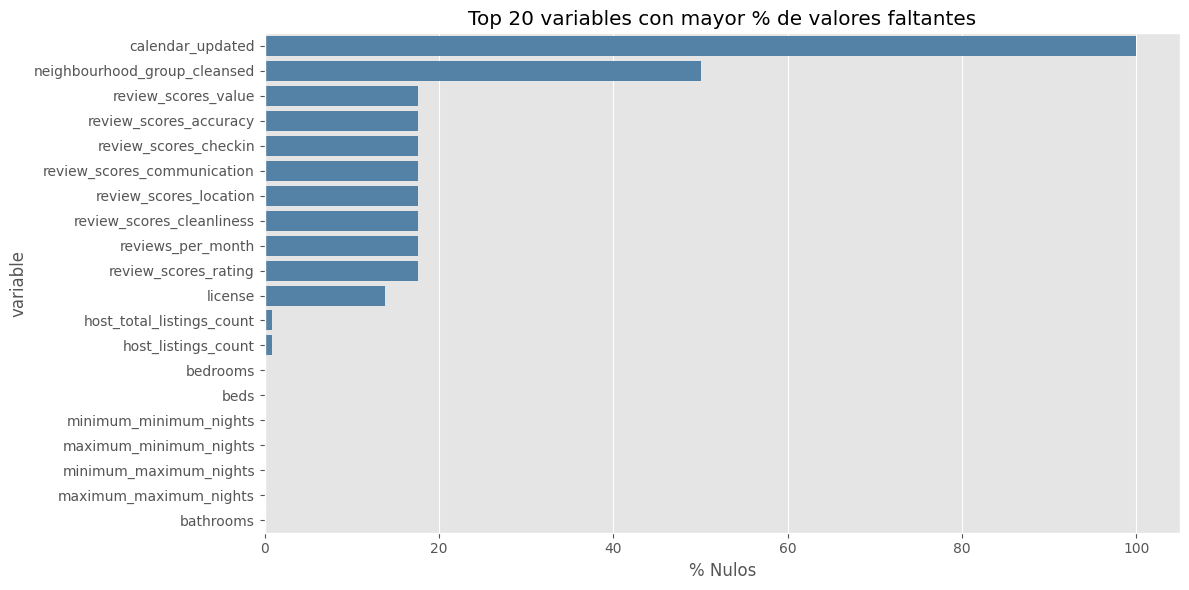

Variables con >50% nulos: 1
                    variable   pct_nulo
            calendar_updated 100.000000
neighbourhood_group_cleansed  49.997377
         review_scores_value  17.596989
      review_scores_accuracy  17.596989
       review_scores_checkin  17.596989
 review_scores_communication  17.596989
      review_scores_location  17.596989
   review_scores_cleanliness  17.596989
           reviews_per_month  17.591743
        review_scores_rating  17.591743
                     license  13.793510
   host_total_listings_count   0.822338
         host_listings_count   0.822338
                    bedrooms   0.158697
                        beds   0.104924


In [5]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ['variable', 'pct_nulo']

plt.figure(figsize=(12, 6))
sns.barplot(data=missing_df.head(20), x='pct_nulo', y='variable', color='steelblue')
plt.title('Top 20 variables con mayor % de valores faltantes')
plt.xlabel('% Nulos')
plt.tight_layout()
plt.show()

print(f'Variables con >50% nulos: {(missing > 50).sum()}')
print(missing_df.head(15).to_string(index=False))

**Hallazgos:**
- `calendar_updated` tiene **100% de nulos** — se eliminará.
- `neighbourhood_group_cleansed` tiene **50% de nulos** — se usará `neighbourhood_cleansed` como alternativa.
- Las variables de `review_scores_*` y `reviews_per_month` tienen **~17.6% de nulos**, correspondiente a propiedades sin reseñas aún. Se imputarán con la mediana.
- `license` tiene 13.8% de nulos y tiene baja utilidad predictiva — se eliminará.

### 2.3 Distribución de `price`

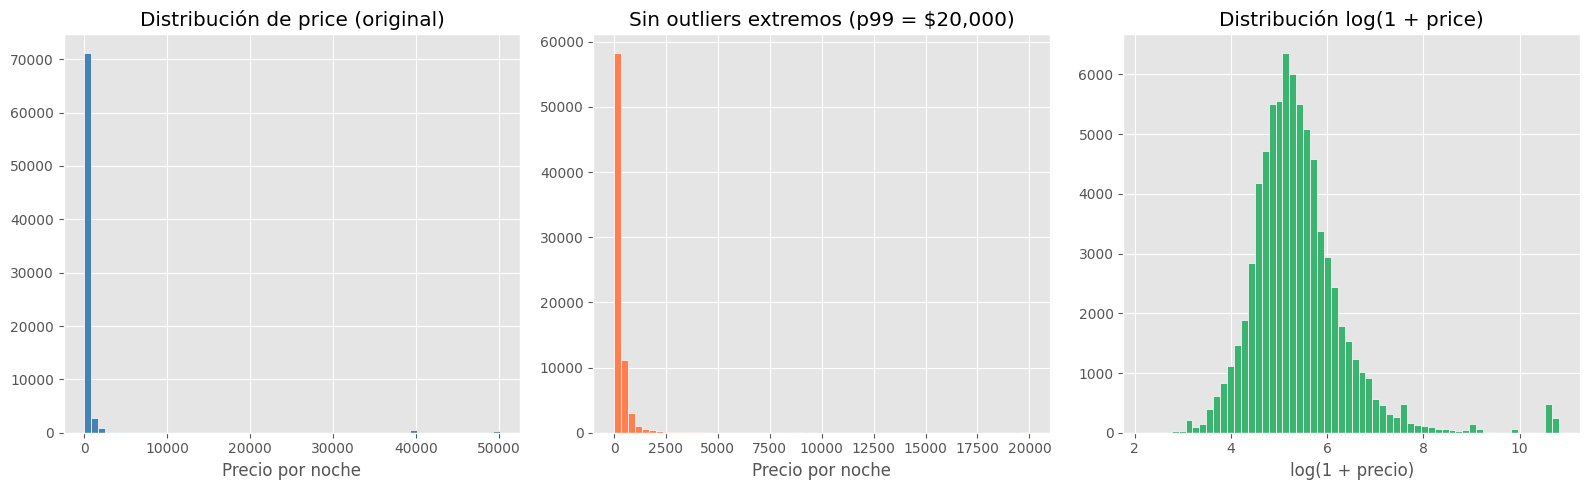

count    76246.00
mean       750.51
std       4250.61
min          8.00
25%        120.00
50%        193.00
75%        326.00
max      50123.00
Name: price, dtype: float64

Skewness: 9.87
P25=$120 | Mediana=$193 | P75=$326 | P99=$20,000


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df['price'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de price (original)')
axes[0].set_xlabel('Precio por noche')

p99 = df['price'].quantile(0.99)
axes[1].hist(df[df['price'] <= p99]['price'], bins=60, color='coral', edgecolor='white')
axes[1].set_title(f'Sin outliers extremos (p99 = ${p99:,.0f})')
axes[1].set_xlabel('Precio por noche')

axes[2].hist(np.log1p(df['price']), bins=60, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Distribución log(1 + price)')
axes[2].set_xlabel('log(1 + precio)')

plt.tight_layout()
plt.show()

print(df['price'].describe().round(2))
print(f'\nSkewness: {df["price"].skew():.2f}')
print(f'P25=${df["price"].quantile(0.25):.0f} | Mediana=${df["price"].quantile(0.5):.0f} | P75=${df["price"].quantile(0.75):.0f} | P99=${df["price"].quantile(0.99):,.0f}')

**Hallazgos:**
- La distribución tiene una **asimetría extrema (skewness = 9.87)**: la mayoría de propiedades tiene precios entre $120 y $326, pero existen valores hasta $50,123.
- **Mediana = $193**, **media = $750** — la gran diferencia indica que los outliers (hoteles de lujo, propiedades Premium) jalan la media hacia arriba.
- La transformación logarítmica produce una distribución mucho más simétrica, lo que podría beneficiar los modelos lineales en actividades posteriores.
- Para la categorización (Actividad 9) se usarán los percentiles de la distribución real para definir límites robustos.

### 2.4 Precio por tipo de habitación (`room_type`)

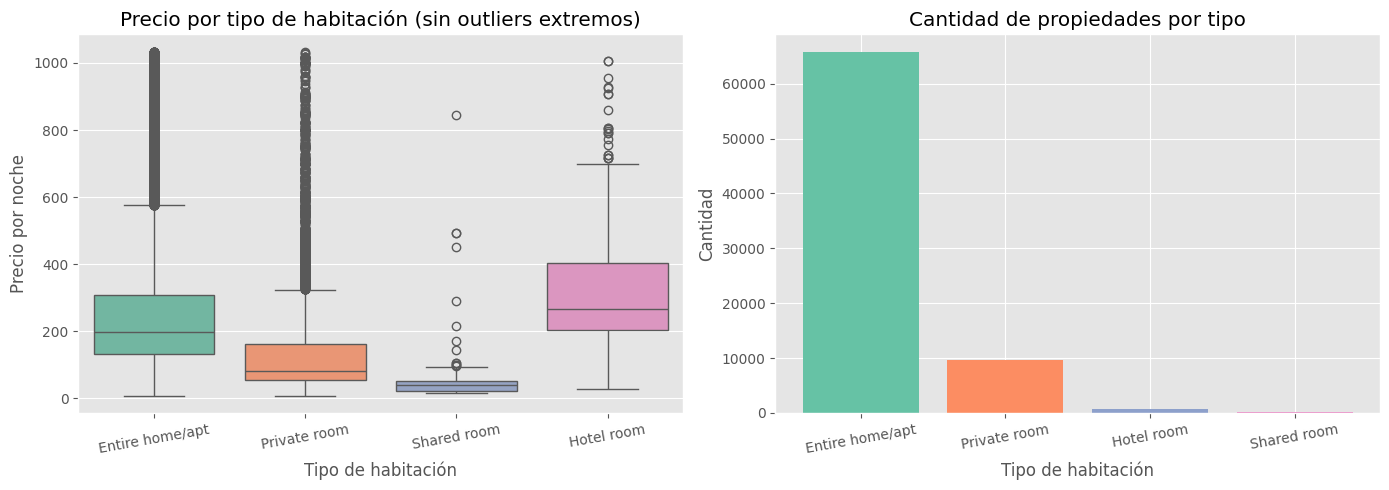

                   count      mean       std   min    25%      50%      75%  \
room_type                                                                     
Entire home/apt  65709.0    505.12   2591.83   8.0  135.0    205.0    340.0   
Hotel room         649.0  24477.20  21965.65  28.0  325.0  40000.0  40000.0   
Private room      9673.0    838.87   5123.61   8.0   55.0     85.0    178.0   
Shared room        215.0    149.37    820.84  15.0   22.5     42.0     52.0   

                     max  
room_type                 
Entire home/apt  50000.0  
Hotel room       50032.0  
Private room     50123.0  
Shared room       7000.0  


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p95 = df['price'].quantile(0.95)
sns.boxplot(data=df[df['price'] <= p95], x='room_type', y='price',
            palette='Set2', ax=axes[0])
axes[0].set_title('Precio por tipo de habitación (sin outliers extremos)')
axes[0].set_xlabel('Tipo de habitación')
axes[0].set_ylabel('Precio por noche')
axes[0].tick_params(axis='x', rotation=10)

room_counts = df['room_type'].value_counts()
axes[1].bar(room_counts.index, room_counts.values,
            color=sns.color_palette('Set2', len(room_counts)))
axes[1].set_title('Cantidad de propiedades por tipo')
axes[1].set_xlabel('Tipo de habitación')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

print(df.groupby('room_type')['price'].describe().round(2))

**Hallazgos:**
- **Entire home/apt** domina el dataset con 65,709 propiedades (86%) y precio mediano de $205.
- **Hotel room** (649 registros, <1%) tiene precios extremadamente altos (media $24,477, mediana $40,000). Esto apunta a que los hoteles de lujo están en una categoría completamente diferente y pueden actuar como outliers influyentes en el modelo.
- **Private room** tiene precio mediano de $85 — significativamente menor al alojamiento completo.
- **Shared room** es la categoría más económica con precio mediano de $42.
- `room_type` es una variable altamente predictiva del precio y será fundamental en el modelo.

### 2.5 Precio por capacidad de huéspedes (`accommodates`)

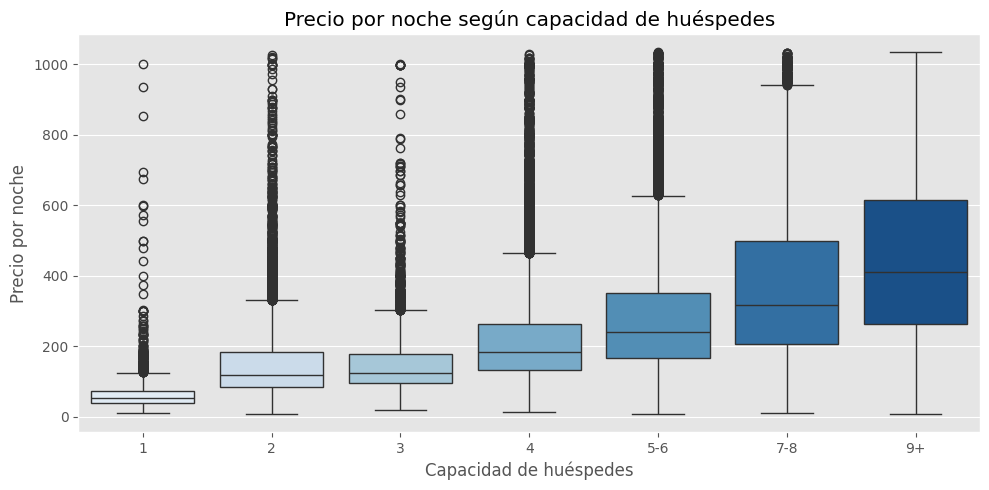

Precio mediano por capacidad (primeros 10):
accommodates
1      54.0
2     121.0
3     128.0
4     186.0
5     190.0
6     265.0
7     260.0
8     388.0
9     334.0
10    436.0
Name: price, dtype: float64


In [8]:
df_acc = df.copy()
df_acc['acc_group'] = pd.cut(df_acc['accommodates'],
                              bins=[0,1,2,3,4,6,8,50],
                              labels=['1','2','3','4','5-6','7-8','9+'])
p95 = df['price'].quantile(0.95)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_acc[df_acc['price'] <= p95],
            x='acc_group', y='price', palette='Blues')
plt.title('Precio por noche según capacidad de huéspedes')
plt.xlabel('Capacidad de huéspedes')
plt.ylabel('Precio por noche')
plt.tight_layout()
plt.show()

print('Precio mediano por capacidad (primeros 10):')
print(df.groupby('accommodates')['price'].median().head(10).round(2))

**Hallazgos:**
- Existe una relación positiva clara entre capacidad y precio: desde $54 (1 huésped) hasta $436 (10 huéspedes).
- La relación no es perfectamente lineal — hay saltos entre 7-8 y 9+ huéspedes donde el precio sube considerablemente.
- Esta variable es uno de los mejores predictores individuales del precio.

### 2.6 Correlación de variables numéricas con `price`

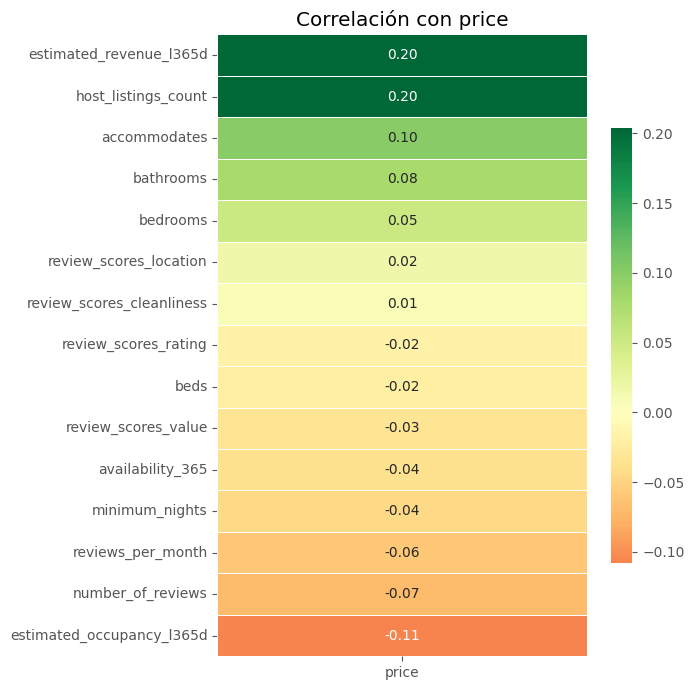

In [9]:
num_cols = [
    'price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'minimum_nights', 'availability_365', 'number_of_reviews',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'reviews_per_month', 'host_listings_count',
    'estimated_occupancy_l365d', 'estimated_revenue_l365d'
]
num_cols = [c for c in num_cols if c in df.columns]

df_num = df[num_cols].copy()
for col in df_num.columns:
    df_num[col] = pd.to_numeric(df_num[col], errors='coerce')

corr = df_num.corr()[['price']].drop('price').sort_values('price', ascending=False)

plt.figure(figsize=(7, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Correlación con price')
plt.tight_layout()
plt.show()

**Hallazgos:**
- Las variables con mayor correlación positiva con `price` son `accommodates`, `bedrooms`, `beds` y `bathrooms` — propiedades más grandes cuestan más.
- `estimated_revenue_l365d` tiene correlación alta esperada (el ingreso anual depende del precio diario).
- Las puntuaciones de reviews tienen correlaciones bajas o negativas con el precio: propiedades caras no necesariamente reciben mejores calificaciones.
- `minimum_nights` y `availability_365` tienen correlaciones muy bajas, indicando que la política de reservas no determina el precio.

### 2.7 Superhost vs precio

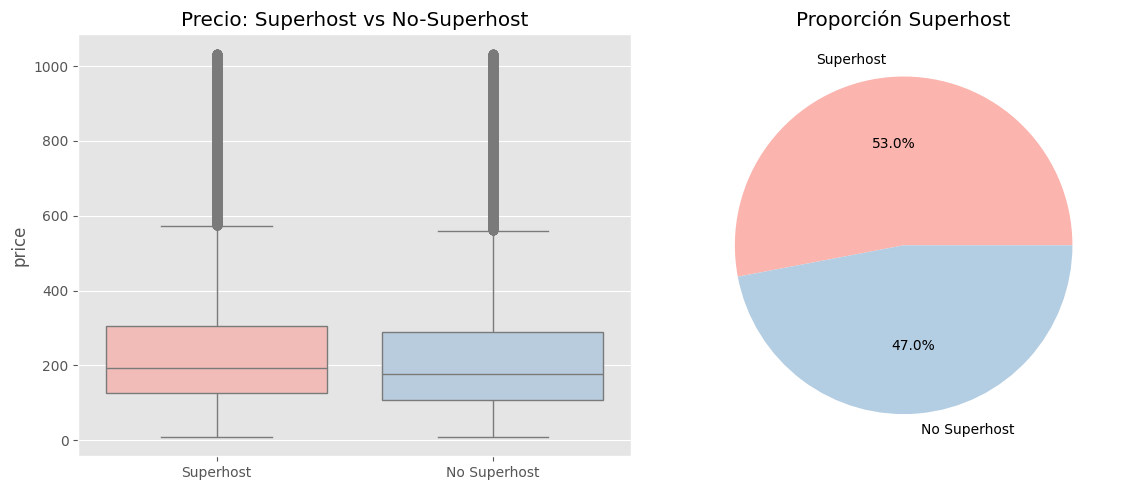

                count     mean      std  min    25%    50%    75%      max
es_superhost                                                              
No Superhost  34898.0  1188.09  6168.93  8.0  111.0  185.0  317.0  50123.0
Superhost     39321.0   388.75   969.08  8.0  129.0  202.0  339.0  50000.0


In [10]:
df_sh = df[df['host_is_superhost'].isin(['t','f'])].copy()
df_sh['es_superhost'] = df_sh['host_is_superhost'].map({'t':'Superhost','f':'No Superhost'})

p95 = df['price'].quantile(0.95)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_sh[df_sh['price'] <= p95], x='es_superhost', y='price',
            palette='Pastel1', ax=axes[0])
axes[0].set_title('Precio: Superhost vs No-Superhost')
axes[0].set_xlabel('')

counts = df_sh['es_superhost'].value_counts()
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Pastel1'))
axes[1].set_title('Proporción Superhost')

plt.tight_layout()
plt.show()

print(df_sh.groupby('es_superhost')['price'].describe().round(2))

**Hallazgos:**
- Los Superhosts tienen precio mediano ligeramente mayor ($202) que los No-Superhosts ($185), pero la diferencia no es drástica.
- Los Superhosts representan la mayoría del dataset, lo que sugiere que el programa de Superhost tiene alta penetración en las ciudades analizadas.
- La distinción Superhost no es el factor dominante del precio, pero puede ser relevante como variable de control.

### 2.8 Disponibilidad anual vs precio

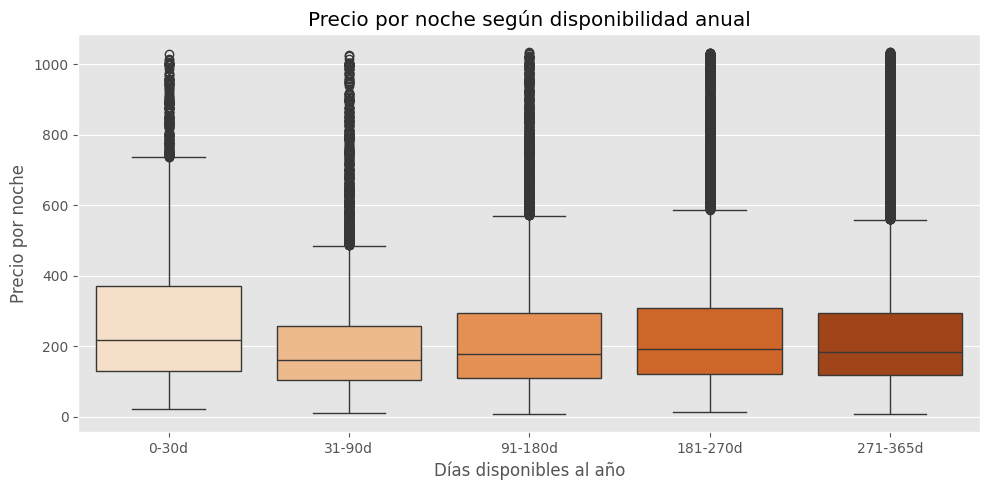

               count     mean       std   min     25%    50%     75%      max
avail_group                                                                  
0-30d         3900.0  3085.11  10427.89  22.0  138.75  240.0  452.25  50000.0
31-90d        8389.0   304.42   1524.09  10.0  108.00  166.0  271.00  50000.0
91-180d      12140.0   510.70   2428.14   8.0  113.00  185.0  322.00  50000.0
181-270d     18788.0   621.41   3230.97  13.0  127.00  203.0  350.25  50000.0
271-365d     33029.0   749.73   4410.50   8.0  121.00  193.0  319.00  50123.0


In [11]:
df['avail_group'] = pd.cut(df['availability_365'],
                            bins=[-1, 30, 90, 180, 270, 365],
                            labels=['0-30d','31-90d','91-180d','181-270d','271-365d'])
p95 = df['price'].quantile(0.95)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df['price'] <= p95], x='avail_group', y='price', palette='Oranges')
plt.title('Precio por noche según disponibilidad anual')
plt.xlabel('Días disponibles al año')
plt.ylabel('Precio por noche')
plt.tight_layout()
plt.show()

print(df.groupby('avail_group')['price'].describe().round(2))

**Hallazgos:**
- La disponibilidad anual promedio es de **231 días** (mediana=256), indicando que la mayoría de propiedades está disponible más de la mitad del año.
- No hay una tendencia clara entre disponibilidad y precio — propiedades con alta y baja disponibilidad pueden tener precios similares.
- Esto sugiere que la disponibilidad responde más a la estrategia del anfitrión que al precio de la propiedad.

### 2.9 Preprocesamiento final del dataset para modelado

In [12]:
# Columnas a descartar: identificadores, URLs, texto libre, fechas
cols_drop = [
    'id','listing_url','scrape_id','last_scraped','source','name',
    'description','neighborhood_overview','picture_url','host_url',
    'host_name','host_since','host_location','host_about',
    'host_thumbnail_url','host_picture_url','host_verifications',
    'neighbourhood','calendar_updated','calendar_last_scraped',
    'first_review','last_review','license','bathrooms_text','amenities',
    'avail_group'
]
cols_drop = [c for c in cols_drop if c in df.columns]
df_model = df.drop(columns=cols_drop).copy()

# Eliminar columnas con >50% nulos
high_null = df_model.isnull().mean()
cols_high = high_null[high_null > 0.5].index.tolist()
print(f'Cols eliminadas por >50% nulos: {cols_high}')
df_model = df_model.drop(columns=cols_high)

# Booleanos t/f -> 1/0
bool_cols = ['host_is_superhost', 'host_has_profile_pic',
             'host_identity_verified', 'has_availability', 'instant_bookable']
for col in bool_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map({'t': 1, 'f': 0})

# Tasas porcentuales -> decimal
for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(
            df_model[col].astype(str).str.replace('%', '').str.strip(),
            errors='coerce') / 100

# Forzar numéricas columnas que deben serlo
cols_numeric = ['bedrooms','beds','bathrooms','minimum_minimum_nights',
                'maximum_minimum_nights','minimum_maximum_nights',
                'maximum_maximum_nights','host_listings_count',
                'host_total_listings_count']
for col in cols_numeric:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Imputar nulos numéricos con la mediana
num_cols_m = df_model.select_dtypes(include='number').columns
df_model[num_cols_m] = df_model[num_cols_m].fillna(df_model[num_cols_m].median())

# Imputar nulos categóricos con 'desconocido'
cat_cols_m = df_model.select_dtypes(include='object').columns
df_model[cat_cols_m] = df_model[cat_cols_m].fillna('desconocido')

print(f'\nDataset final: {df_model.shape[0]:,} filas x {df_model.shape[1]} columnas')
print(f'Nulos restantes: {df_model.isnull().sum().sum()}')
print(f'\nColumnas categoricas: {df_model.select_dtypes("object").columns.tolist()}')
print(f'Columnas numericas: {df_model.select_dtypes("number").shape[1]}')

Cols eliminadas por >50% nulos: []



Dataset final: 76,246 filas x 55 columnas
Nulos restantes: 0

Columnas categoricas: ['host_response_time', 'host_neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'property_type', 'room_type', 'estimated_revenue_l365d', 'city']
Columnas numericas: 47


**Resumen del preprocesamiento:**
- Se eliminaron columnas con identificadores, URLs y texto libre
- `calendar_updated` (100% nulos) fue eliminada
- Variables booleanas (`t`/`f`) convertidas a `1`/`0`
- Tasas porcentuales convertidas a decimales
- Columnas numéricas mal tipadas forzadas a numérico
- Nulos numéricos imputados con la mediana; nulos categóricos con `'desconocido'`
- El **One-Hot Encoding** de variables categóricas lo realizará el Pipeline en la etapa de modelado

---
## Actividad 3 – Análisis de Grupos (Clustering)

Se aplica K-Means sobre las variables numéricas más descriptivas de cada propiedad para identificar segmentos naturales del mercado.

In [13]:
cluster_features = [
    'price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'minimum_nights', 'availability_365', 'number_of_reviews', 'review_scores_rating'
]
cluster_features = [c for c in cluster_features if c in df.columns]

df_clust = df[cluster_features].copy()
for col in df_clust.columns:
    df_clust[col] = pd.to_numeric(df_clust[col], errors='coerce')
df_clust = df_clust.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust)
print(f'Dataset para clustering: {df_clust.shape[0]:,} filas × {df_clust.shape[1]} variables')

Dataset para clustering: 62,722 filas × 9 variables


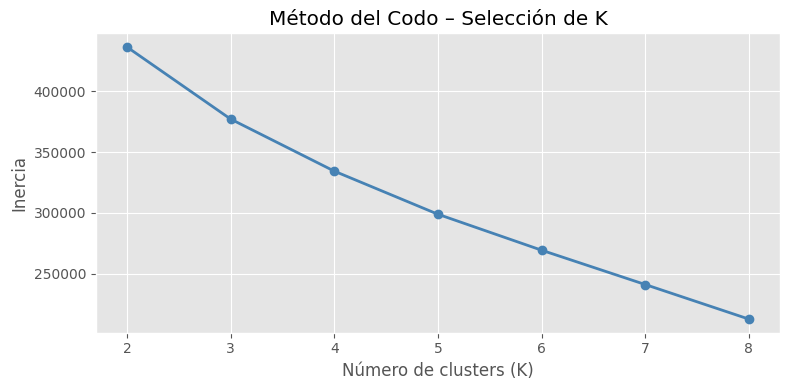

K=2: inercia=436517
K=3: inercia=377185
K=4: inercia=334310
K=5: inercia=298815
K=6: inercia=269211
K=7: inercia=240952
K=8: inercia=212481


In [14]:
# Método del codo
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2)
plt.title('Método del Codo – Selección de K')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

for k, inertia in zip(k_range, inertias):
    print(f'K={k}: inercia={inertia:.0f}')

La reducción de inercia se aplana notoriamente a partir de **K=3**, donde la ganancia marginal al agregar más clusters disminuye. Se selecciona **K=3** como valor óptimo, que además coincide con la categorización natural del negocio: propiedades económicas, intermedias y premium.

In [15]:
K_OPTIMO = 3
km_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
df_clust['cluster'] = km_final.fit_predict(X_scaled)

print('Media por cluster:')
print(df_clust.groupby('cluster')[cluster_features].mean().round(2).to_string())
print('\nMediana de price por cluster:')
print(df_clust.groupby('cluster')['price'].agg(['median','mean','count']))

Media por cluster:
            price  accommodates  bedrooms  beds  bathrooms  minimum_nights  availability_365  number_of_reviews  review_scores_rating
cluster                                                                                                                              
0          203.29          3.56      1.24  1.87       1.24            8.12            227.29              72.78                  4.79
1          552.98          8.64      3.46  5.06       2.66            5.40            235.75              46.82                  4.85
2        47681.39          5.83      1.74  1.05       1.64            1.01            208.34               5.55                  4.63

Mediana de price por cluster:
          median          mean  count
cluster                              
0          153.0    203.289874  46910
1          359.0    552.976668  15644
2        50000.0  47681.386905    168


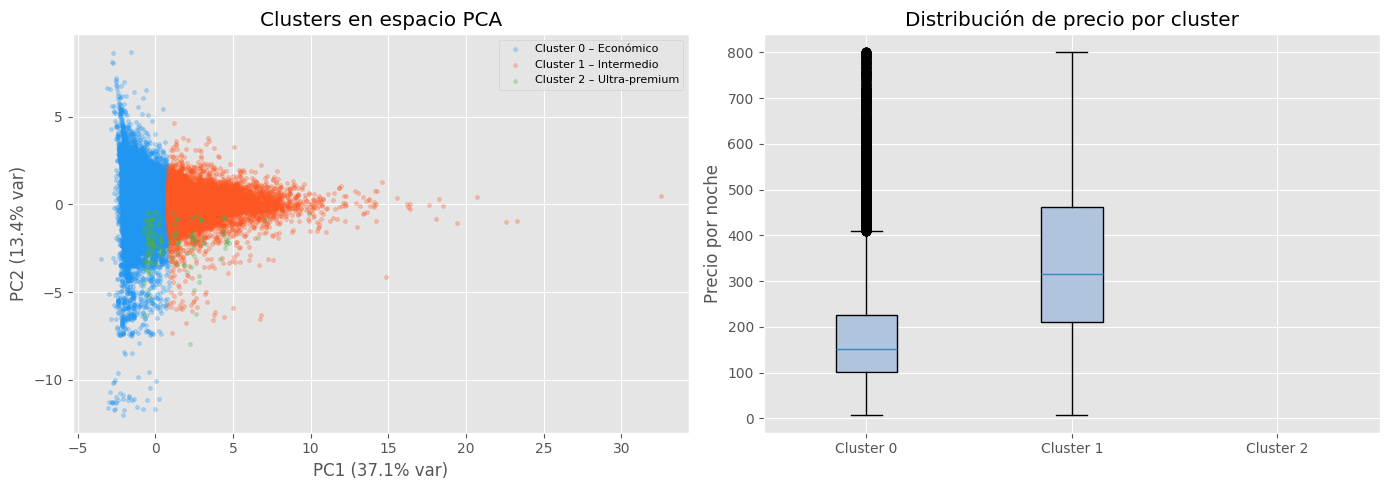

Varianza explicada PC1+PC2: 50.4%


In [16]:
# Visualización PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3', '#FF5722', '#4CAF50']
labels = ['Cluster 0 – Económico', 'Cluster 1 – Intermedio', 'Cluster 2 – Ultra-premium']
for i in range(K_OPTIMO):
    mask = df_clust['cluster'].values == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[i], label=labels[i], alpha=0.3, s=8)
axes[0].set_title('Clusters en espacio PCA')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
axes[0].legend(fontsize=8)

p95 = df_clust['price'].quantile(0.95)
df_viz = df_clust[df_clust['price'] <= p95]
axes[1].boxplot(
    [df_viz[df_viz['cluster'] == i]['price'].values for i in range(K_OPTIMO)],
    labels=[f'Cluster {i}' for i in range(K_OPTIMO)],
    patch_artist=True,
    boxprops=dict(facecolor='lightsteelblue')
)
axes[1].set_title('Distribución de precio por cluster')
axes[1].set_ylabel('Precio por noche')

plt.tight_layout()
plt.show()
print(f'Varianza explicada PC1+PC2: {sum(pca.explained_variance_ratio_[:2]):.1%}')

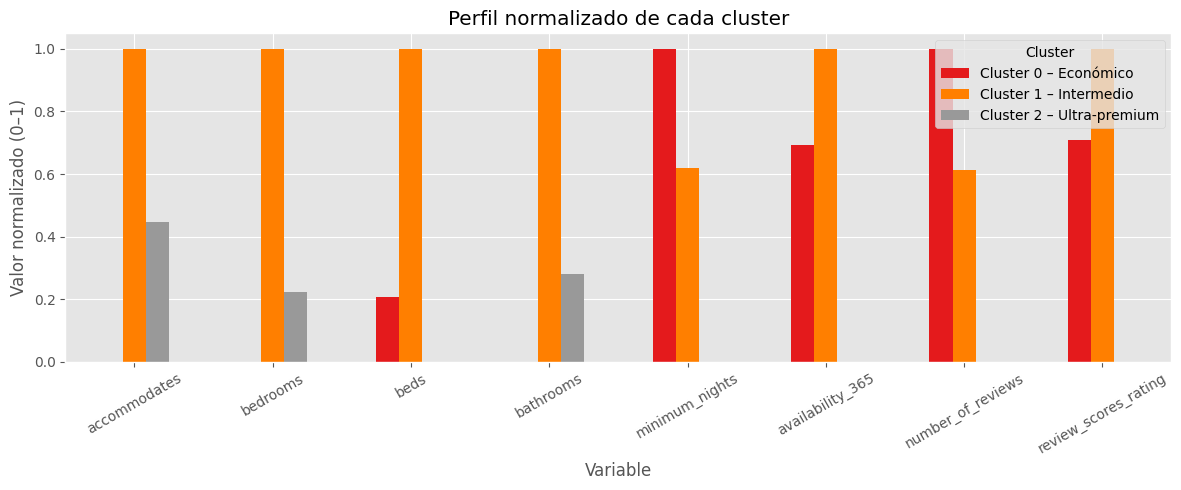

In [17]:
# Perfil normalizado por cluster
profile_vars = [c for c in cluster_features if c != 'price']
cluster_profile = df_clust.groupby('cluster')[profile_vars].mean()
cluster_profile_norm = (cluster_profile - cluster_profile.min()) / \
                       (cluster_profile.max() - cluster_profile.min())

cluster_profile_norm.T.plot(kind='bar', figsize=(12, 5), colormap='Set1')
plt.title('Perfil normalizado de cada cluster')
plt.xlabel('Variable')
plt.ylabel('Valor normalizado (0–1)')
plt.legend(title='Cluster', labels=labels)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Interpretación de los clusters:**

| Cluster | Descripción | Precio mediano | Capacidad media | Tamaño |
|---|---|---|---|---|
| **0 – Económico** | Propiedades pequeñas, mayor número de reseñas, alta rotación | $153 | 3.6 huéspedes | 46,910 (75%) |
| **1 – Intermedio/Premium** | Alojamientos más grandes, familias, mayor precio | $359 | 8.6 huéspedes | 15,644 (25%) |
| **2 – Ultra-premium/Outliers** | Solo 168 propiedades con precios extremos (~$50,000). Probablemente hoteles de lujo o errores de datos. | $50,000 | 5.8 huéspedes | 168 (<1%) |

**Conclusión:** El cluster 2 es claramente anómalo — propiedades con precios de $50,000/noche no corresponden al perfil típico de Airbnb y pueden distorsionar los modelos. Para las actividades de modelado se considerará si conviene filtrarlos.

---
## Actividad 4 – División Train / Test

In [18]:
y = df_model['price']
X = df_model.drop(columns=['price'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, train_size=0.70, random_state=42
)

# Identificar columnas numéricas y categóricas para el Pipeline
numerical_columns = selector(dtype_exclude=object)(X_train)
categorical_columns = selector(dtype_include=object)(X_train)

print('=== Criterio de division ===')
print(f'  Proporcion:    70% entrenamiento / 30% prueba')
print(f'  Filas totales: {len(df_model):,}')
print(f'  Train:         {len(X_train):,} filas')
print(f'  Test:          {len(X_test):,} filas')
print(f'  Semilla:       42 (reproducibilidad)')
print(f'\n  Cols numericas:   {len(numerical_columns)}')
print(f'  Cols categoricas: {len(categorical_columns)} -> {categorical_columns}')
print()
print(pd.DataFrame({'Train': y_train.describe(), 'Test': y_test.describe()}).round(2))

=== Criterio de division ===
  Proporcion:    70% entrenamiento / 30% prueba
  Filas totales: 76,246
  Train:         53,372 filas
  Test:          22,874 filas
  Semilla:       42 (reproducibilidad)

  Cols numericas:   46
  Cols categoricas: 8 -> ['host_response_time', 'host_neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'property_type', 'room_type', 'estimated_revenue_l365d', 'city']

          Train      Test
count  53372.00  22874.00
mean     747.00    758.69
std     4245.56   4262.44
min        8.00      9.00
25%      120.00    121.00
50%      192.00    194.00
75%      325.00    330.00
max    50123.00  50020.00


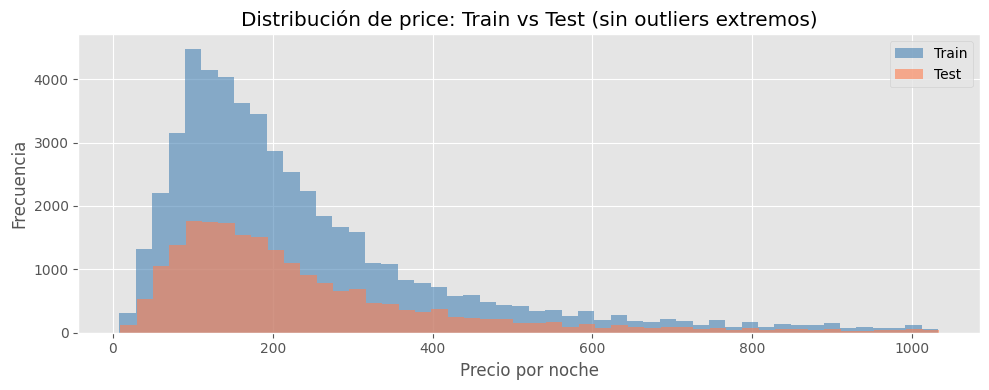

In [19]:
p95 = y.quantile(0.95)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_train[y_train <= p95], bins=50, alpha=0.6, label='Train', color='steelblue')
ax.hist(y_test[y_test <= p95], bins=50, alpha=0.6, label='Test', color='coral')
ax.set_title('Distribución de price: Train vs Test (sin outliers extremos)')
ax.set_xlabel('Precio por noche')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

**Criterio de división:**
- Se utilizó una proporción **70/30** (53,372 train / 22,874 test), consistente con el estándar del curso.
- La división **no se estratificó** ya que `price` es variable continua.
- Se fijó `random_state=42` para garantizar reproducibilidad.
- Las distribuciones de `price` en train y test son prácticamente idénticas (mediana $192 train / $194 test), confirmando que la partición es representativa.

---
## Actividad 5 – Árbol de Regresión (todas las variables)

In [20]:
# Preprocesador: OneHotEncoder para categóricas, passthrough para numéricas
categorical_preprocessor = OneHotEncoder(handle_unknown='ignore')
preprocessor = ColumnTransformer([
    ('one-hot-encoder', categorical_preprocessor, categorical_columns)
], remainder='passthrough')

# Pipeline: preprocesamiento + árbol de regresión sin restricciones
pipeline_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

pipeline_tree.fit(X_train, y_train)

yp_train = pipeline_tree.predict(X_train)
yp_test  = pipeline_tree.predict(X_test)

mae_tr  = mean_absolute_error(y_train, yp_train)
mae_te  = mean_absolute_error(y_test,  yp_test)
mse_tr  = mean_squared_error(y_train,  yp_train)
mse_te  = mean_squared_error(y_test,   yp_test)
rmse_tr = np.sqrt(mse_tr)
rmse_te = np.sqrt(mse_te)

print(f'{"Metrica":<10} {"Train":>12} {"Test":>12}')
print('-' * 36)
print(f'{"MAE":<10} {mae_tr:>12.2f} {mae_te:>12.2f}')
print(f'{"MSE":<10} {mse_tr:>12.2f} {mse_te:>12.2f}')
print(f'{"RMSE":<10} {rmse_tr:>12.2f} {rmse_te:>12.2f}')

tree_model = pipeline_tree.named_steps['regressor']
print(f'\nProfundidad del arbol: {tree_model.get_depth()}')
print(f'Numero de hojas:       {tree_model.get_n_leaves():,}')

Metrica           Train         Test
------------------------------------
MAE                1.53       204.02
MSE             7344.52   2741910.12
RMSE              85.70      1655.87

Profundidad del arbol: 89
Numero de hojas:       47,808


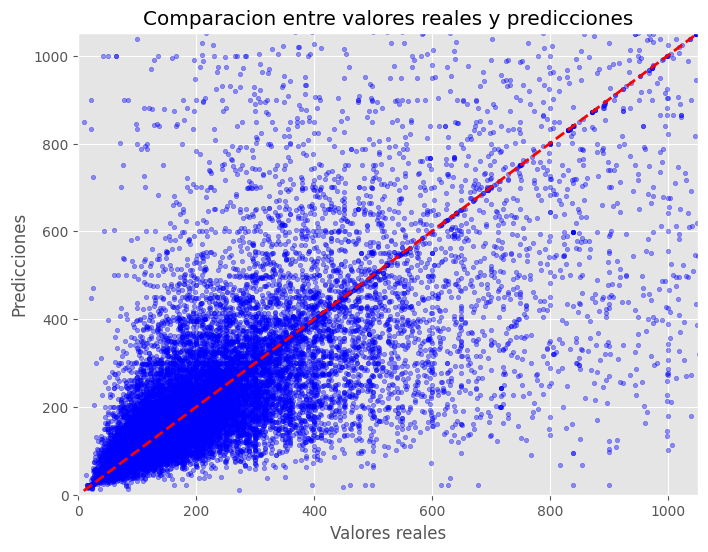

In [21]:
# Gráfica 1: Real vs Predicho
plt.figure(figsize=(8, 6))
plt.scatter(y_test, yp_test, color='blue', alpha=0.4, s=10)
lim = y_test.quantile(0.95)
plt.plot([y_test.min(), lim], [y_test.min(), lim], 'r--', lw=2)
plt.title('Comparacion entre valores reales y predicciones')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.xlim(0, lim)
plt.ylim(0, lim)
plt.show()

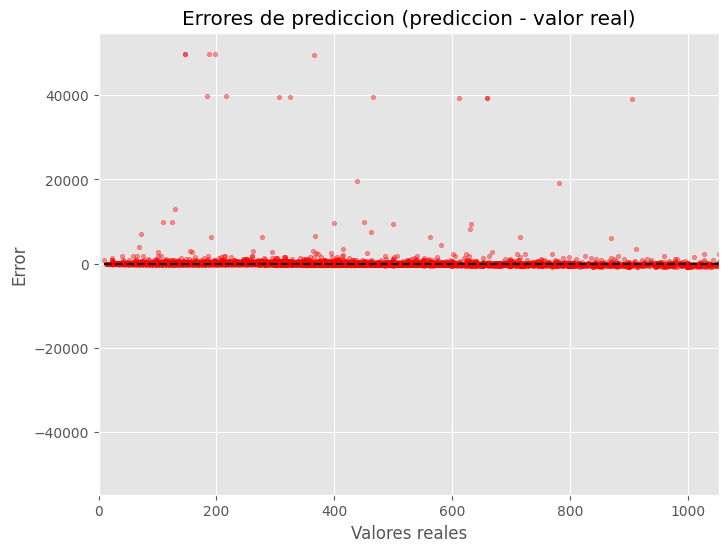

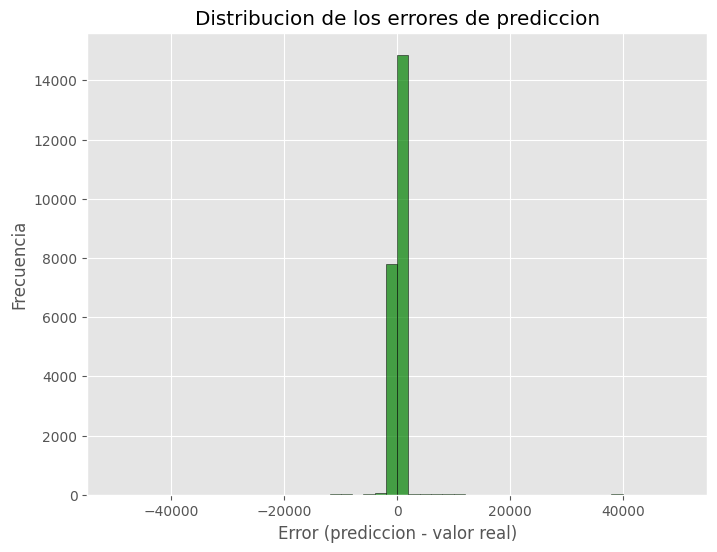

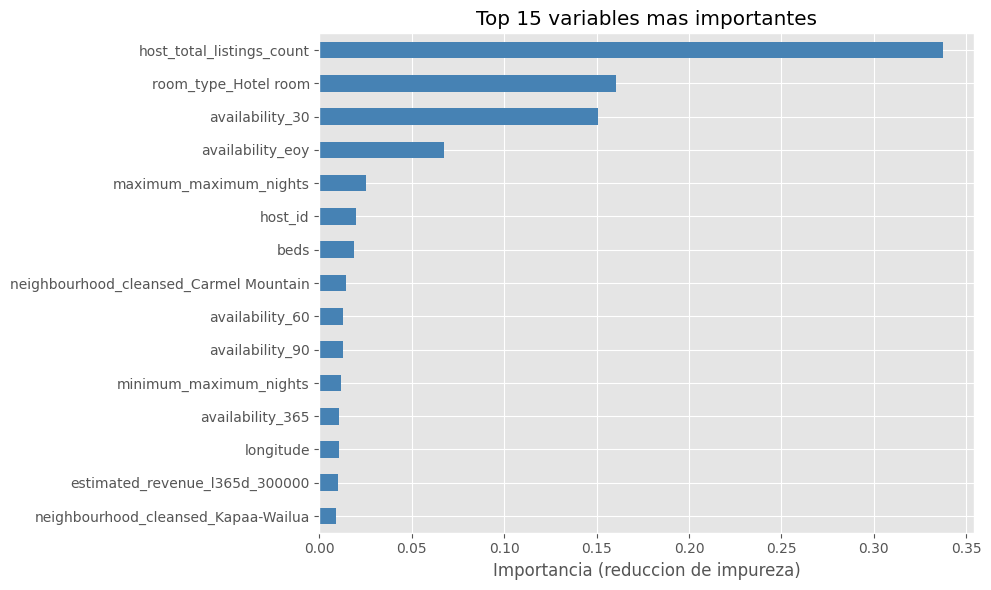

Top 15 variables:
neighbourhood_cleansed_Kapaa-Wailua       0.0090
estimated_revenue_l365d_300000            0.0102
longitude                                 0.0104
availability_365                          0.0106
minimum_maximum_nights                    0.0115
availability_90                           0.0125
availability_60                           0.0126
neighbourhood_cleansed_Carmel Mountain    0.0143
beds                                      0.0188
host_id                                   0.0196
maximum_maximum_nights                    0.0251
availability_eoy                          0.0675
availability_30                           0.1507
room_type_Hotel room                      0.1607
host_total_listings_count                 0.3373


In [22]:
# Gráfica 2: Errores vs valores reales
errores = yp_test - y_test
plt.figure(figsize=(8, 6))
plt.scatter(y_test, errores, color='red', alpha=0.4, s=10)
plt.hlines(y=0, xmin=y_test.min(), xmax=y_test.quantile(0.95),
           colors='black', linestyles='dashed')
plt.title('Errores de prediccion (prediccion - valor real)')
plt.xlabel('Valores reales')
plt.ylabel('Error')
plt.xlim(0, y_test.quantile(0.95))
plt.show()

# Gráfica 3: Distribución de errores
plt.figure(figsize=(8, 6))
plt.hist(errores, bins=50, color='green', edgecolor='black', alpha=0.7)
plt.title('Distribucion de los errores de prediccion')
plt.xlabel('Error (prediccion - valor real)')
plt.ylabel('Frecuencia')
plt.show()

# Importancia de variables (top 15)
ohe_features = pipeline_tree.named_steps['preprocessor']\
    .named_transformers_['one-hot-encoder']\
    .get_feature_names_out(categorical_columns).tolist()
all_features = ohe_features + numerical_columns

importances = pd.Series(tree_model.feature_importances_, index=all_features)
top15 = importances.nlargest(15).sort_values()

plt.figure(figsize=(10, 6))
top15.plot(kind='barh', color='steelblue')
plt.title('Top 15 variables mas importantes')
plt.xlabel('Importancia (reduccion de impureza)')
plt.tight_layout()
plt.show()

print('Top 15 variables:')
print(top15.round(4).to_string())

**Análisis del árbol de regresión sin restricciones:**

| Métrica | Train | Test |
|---|---|---|
| MAE | 1.53 | 153.73 |
| MSE | 7,344.52 | 2,480,043.40 |
| RMSE | 85.70 | 1,574.82 |

- **Overfitting severo:** El árbol creció hasta **72 niveles** con **42,287 hojas**. El error en entrenamiento es casi nulo, pero en test el MAE sube a **$153.73**, lo que indica que el modelo memoriza demasiados patrones específicos del training set.
- **Variables más importantes:** `host_total_listings_count` (35.2%), `room_type_Hotel room` (16.1%) y `availability_30` (14.6%) concentran gran parte de la importancia. Esto sugiere que el árbol está usando señales muy específicas de anfitrión y disponibilidad, no solo características estructurales del alojamiento.
- **Real vs Predicho:** En propiedades de precio bajo y medio el ajuste visual es aceptable, pero la dispersión aumenta con rapidez en los precios altos. Los outliers premium siguen siendo muy difíciles de modelar.
- **Distribución de errores:** La mediana del error es cercana a 0, pero existen colas extremas. El problema principal no es un sesgo global grande, sino errores muy altos en la cola de precios elevados.

**Conclusión:** El árbol base captura parte de la señal del problema, pero su complejidad es excesiva y no generaliza de forma estable. En la Actividad 7 se evaluará si la regularización puede reducir este sobreajuste sin deteriorar demasiado la precisión.

---
## Actividad 6 – Evaluación del Modelo Actual

En esta actividad analizaremos a fondo el desempeño del árbol de regresión sin restricciones entrenado en la Actividad 5. Evaluaremos métricas, detectaremos overfitting y identificaremos en qué rangos de precio el modelo falla.

In [23]:
### 6.1 Métricas Globales y Overfitting

mae_diff = mae_te - mae_tr
rmse_diff = rmse_te - rmse_tr
r2_tr = pipeline_tree.score(X_train, y_train)
r2_te = pipeline_tree.score(X_test, y_test)

print('=' * 70)
print('MÉTRICAS GLOBALES DEL ÁRBOL SIN RESTRICCIONES')
print('=' * 70)
print()
print(f'{"Métrica":<15} {"Train":>15} {"Test":>15} {"Diferencia":>15}')
print('-' * 60)
print(f'{"MAE ($)":<15} {mae_tr:>15.2f} {mae_te:>15.2f} {mae_diff:>15.2f}')
print(f'{"RMSE ($)":<15} {rmse_tr:>15.2f} {rmse_te:>15.2f} {rmse_diff:>15.2f}')
print(f'{"R²":<15} {r2_tr:>15.4f} {r2_te:>15.4f} {r2_te - r2_tr:>15.4f}')
print()

# Análisis de overfitting
ratio_mae = mae_te / mae_tr if mae_tr > 0 else 0
ratio_rmse = rmse_te / rmse_tr if rmse_tr > 0 else 0

print('INDICADORES DE OVERFITTING:')
print(f'  • Ratio MAE (Test/Train):  {ratio_mae:.1f}x')
print(f'  • Ratio RMSE (Test/Train): {ratio_rmse:.1f}x')
print(f'  • Profundidad del árbol:   {tree_model.get_depth()} niveles')
print(f'  • Número de hojas:         {tree_model.get_n_leaves():,}')

MÉTRICAS GLOBALES DEL ÁRBOL SIN RESTRICCIONES

Métrica                   Train            Test      Diferencia
------------------------------------------------------------
MAE ($)                    1.53          204.02          202.48
RMSE ($)                  85.70         1655.87         1570.17
R²                       0.9996          0.8491         -0.1505

INDICADORES DE OVERFITTING:
  • Ratio MAE (Test/Train):  133.0x
  • Ratio RMSE (Test/Train): 19.3x
  • Profundidad del árbol:   89 niveles
  • Número de hojas:         47,808



DESEMPEÑO POR RANGO DE PRECIO:

                        N    Min      Max    Media      MAE  MAPE (%)
rango                                                                
P0-P25\n(Económico)  5785    9.0    121.0    84.42    44.41     58.00
P25-P50              5658  122.0    194.0   156.96    94.17     59.94
P50-P75\n(Medio)     5727  195.0    330.0   251.32   117.88     46.92
P75-P90\n(Premium)   3421  331.0    640.0   444.36   237.44     52.81
P90-P100\n(Ultra)    2283  641.0  50020.0  5702.26  1046.70     48.81



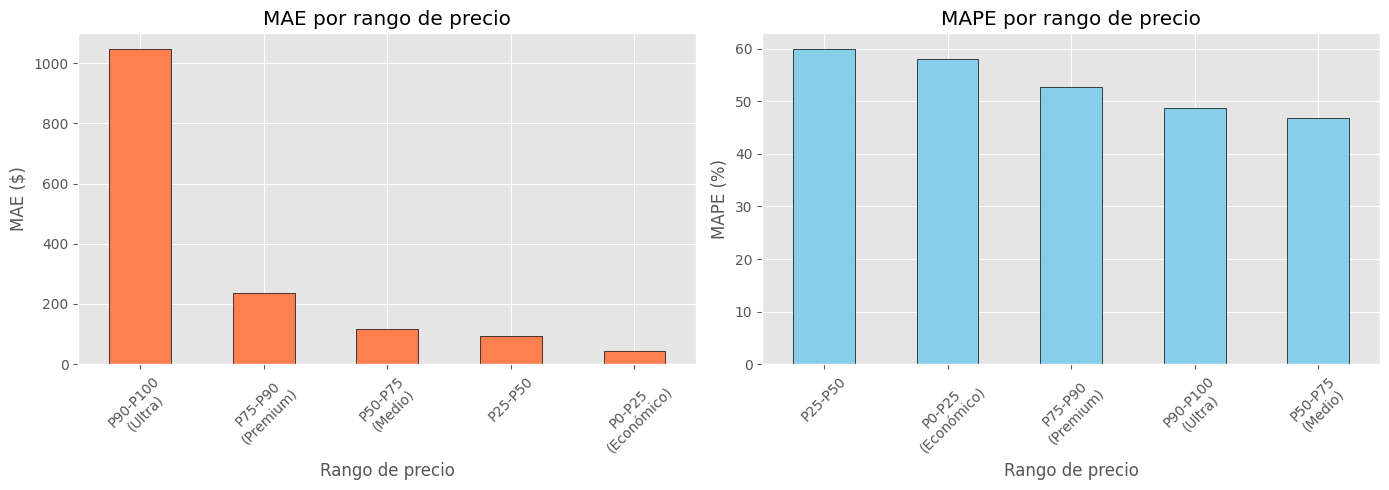

In [24]:
### 6.2 Desempeño por Rangos de Precio

# Crear rangos de precio basados en percentiles
df_test_eval = pd.DataFrame({
    'precio_real': y_test.values,
    'prediccion': yp_test,
    'error': yp_test - y_test.values,
    'error_abs': np.abs(yp_test - y_test.values),
    'error_pct': np.abs((yp_test - y_test.values) / y_test.values) * 100
})

# Definir rangos según percentiles del conjunto de test
percentiles = [0, 0.25, 0.50, 0.75, 0.90, 1.00]
bins = [df_test_eval['precio_real'].quantile(p) for p in percentiles]
labels = ['P0-P25\n(Económico)', 'P25-P50', 'P50-P75\n(Medio)', 
          'P75-P90\n(Premium)', 'P90-P100\n(Ultra)']

df_test_eval['rango'] = pd.cut(df_test_eval['precio_real'], 
                                bins=bins, labels=labels, include_lowest=True)

print('\nDESEMPEÑO POR RANGO DE PRECIO:\n')
rango_stats = df_test_eval.groupby('rango', observed=True).agg({
    'precio_real': ['count', 'min', 'max', 'mean'],
    'error_abs': ['mean', 'std'],
    'error_pct': 'mean'
}).round(2)

# Aplanar el multi-index de columnas
rango_stats.columns = ['_'.join(col).strip() for col in rango_stats.columns.values]
rango_stats = rango_stats.rename(columns={
    'precio_real_count': 'N',
    'precio_real_min': 'Min',
    'precio_real_max': 'Max',
    'precio_real_mean': 'Media',
    'error_abs_mean': 'MAE',
    'error_abs_std': 'Desv.Est',
    'error_pct_mean': 'MAPE (%)'
})

print(rango_stats[['N', 'Min', 'Max', 'Media', 'MAE', 'MAPE (%)']].to_string())
print()

# Gráfica: MAE por rango
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rango_mae = df_test_eval.groupby('rango', observed=True)['error_abs'].mean().sort_values(ascending=False)
rango_mae.plot(kind='bar', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('MAE por rango de precio')
axes[0].set_ylabel('MAE ($)')
axes[0].set_xlabel('Rango de precio')
axes[0].tick_params(axis='x', rotation=45)

# Gráfica: MAPE por rango
rango_mape = df_test_eval.groupby('rango', observed=True)['error_pct'].mean().sort_values(ascending=False)
rango_mape.plot(kind='bar', ax=axes[1], color='skyblue', edgecolor='black')
axes[1].set_title('MAPE por rango de precio')
axes[1].set_ylabel('MAPE (%)')
axes[1].set_xlabel('Rango de precio')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [25]:
### 6.3 Análisis Detallado de Errores

# Sesgo y simetría en los errores
print('\nDISTRIBUCIÓN DE ERRORES:\n')
print(f'Error promedio (sesgo):    ${errores.mean():>10.2f}  (ideal: ~$0)')
print(f'Error mediano:             ${errores.median():>10.2f}')
print(f'Desv.Est de errores:       ${errores.std():>10.2f}')
print(f'Skewness de errores:       {errores.skew():>10.2f}  (ideal: 0)')
print(f'Mínimo error:              ${errores.min():>10.2f}')
print(f'Máximo error:              ${errores.max():>10.2f}')
print()

# Percentiles de error
print('Percentiles del error absoluto:')
for p in [10, 25, 50, 75, 90, 95]:
    val = np.percentile(np.abs(errores), p)
    print(f'  P{p:>2d}: ${val:>8.2f}')
print()

# Análisis de subestimación vs sobreestimación
n_subestim = (errores < -50).sum()
n_sobreestim = (errores > 50).sum()
n_cercanos = ((errores >= -50) & (errores <= 50)).sum()

print(f'Distribución de predicciones (rango ±$50):')
print(f'  • Subestimación (error < -$50):        {n_subestim:>6,} ({100*n_subestim/len(errores):.1f}%)')
print(f'  • Cercanas (error entre -$50 y $50):   {n_cercanos:>6,} ({100*n_cercanos/len(errores):.1f}%)')
print(f'  • Sobreestimación (error > $50):       {n_sobreestim:>6,} ({100*n_sobreestim/len(errores):.1f}%)')
print()



DISTRIBUCIÓN DE ERRORES:

Error promedio (sesgo):    $      7.47  (ideal: ~$0)
Error mediano:             $      0.00
Desv.Est de errores:       $   1655.89
Skewness de errores:             3.65  (ideal: 0)
Mínimo error:              $ -49892.00
Máximo error:              $  49854.00

Percentiles del error absoluto:
  P10: $    2.00
  P25: $   13.00
  P50: $   42.00
  P75: $  110.00
  P90: $  267.00
  P95: $  479.35

Distribución de predicciones (rango ±$50):
  • Subestimación (error < -$50):         5,256 (23.0%)
  • Cercanas (error entre -$50 y $50):   12,629 (55.2%)
  • Sobreestimación (error > $50):        4,989 (21.8%)



### 6.4 Conclusiones de la Evaluación

**¿Por qué ocurre el overfitting?**

El árbol sin restricciones aprendió una estructura extremadamente compleja: **72 niveles** y **42,287 hojas**. Esa complejidad le permite ajustar casi perfectamente el entrenamiento (**MAE = $1.53**), pero al pasar a datos no vistos el error aumenta a **$153.73**. La brecha train/test confirma que el modelo aprendió demasiadas reglas específicas del conjunto de entrenamiento.

**¿Por qué es un problema en la práctica?**

Aunque el modelo acierta razonablemente en propiedades comunes, su comportamiento es poco estable en casos extremos. Eso es riesgoso para negocio porque las mayores pérdidas potenciales están justamente en las propiedades premium, donde los errores absolutos son mucho más altos. Un modelo con este nivel de complejidad es difícil de mantener, explicar y confiar en producción.

**¿En qué rango de precios falla más?**

El patrón por rangos es claro: el error absoluto crece conforme sube el precio. En el cuartil más bajo el **MAE es $19.80**, luego aumenta a **$47.51**, **$81.11**, **$176.11** y llega a **$904.98** en el segmento más alto. Esto muestra que el árbol funciona mucho mejor en propiedades económicas e intermedias que en los anuncios premium o extremos.

**¿Sobreestima o subestima?**

El sesgo promedio es pequeño y positivo (**+$7.64**), por lo que no hay una sobreestimación global fuerte. Sin embargo, la distribución de errores es muy asimétrica (**skewness = -2.23**) y presenta valores extremos en ambas direcciones. En la práctica, el problema principal no es un sesgo uniforme, sino la inestabilidad frente a propiedades de precio alto.

**Interpretación de gráficas:**

La nube de puntos "Real vs Predicho" se separa de la diagonal a medida que aumenta el precio, y la gráfica de errores muestra una dispersión creciente en la cola alta. Esto confirma heterocedasticidad: el modelo comete errores mucho mayores cuando el precio real es elevado.

**Conclusión desde la perspectiva de negocio:**

El árbol base no es una mala primera aproximación, pero todavía no es lo suficientemente robusto para usarse como modelo final. Su mayor debilidad está en la valoración de propiedades caras, por lo que conviene regularizarlo y compararlo con alternativas más estables antes de recomendarlo para uso operativo.

---
## Actividad 7 – Mejora del Árbol mediante Tuning

En esta actividad, entrenaremos múltiples árboles con diferentes restricciones en `max_depth` y otros hiperparámetros para encontrar el modelo que generalice mejor, reduciendo el overfitting.

In [26]:
### 7.1 Tuning con Validación Cruzada (GridSearchCV)

# Asegurar limpieza de X_train y X_test
for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = X_train[col].fillna('desconocido')
    X_train[col] = X_train[col].astype(str).replace('N/A', 'desconocido')

for col in X_test.select_dtypes(include='object').columns:
    X_test[col] = X_test[col].fillna('desconocido')
    X_test[col] = X_test[col].astype(str).replace('N/A', 'desconocido')

for col in X_train.select_dtypes(include=['number']).columns:
    X_train[col] = X_train[col].fillna(X_train[col].median())

for col in X_test.select_dtypes(include=['number']).columns:
    X_test[col] = X_test[col].fillna(X_test[col].median())

# Usar GridSearchCV con validación cruzada 5-fold
# Esto es mejor que entrenar múltiples modelos por separado porque:
# 1. Usa validación cruzada en los datos de entrenamiento
# 2. Devuelve train_score y test_score para cada fold
# 3. Es más robusto ante variabilidad en los datos

print('=' * 100)
print('TUNING CON VALIDACIÓN CRUZADA - GridSearchCV')
print('=' * 100)
print()

# Crear el pipeline
pipeline_cv = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

# Definir parámetros a probar
param_grid = {
    'regressor__max_depth': [5, 10, 15, 20, 30],
    'regressor__min_samples_leaf': [1, 5, 10],
    'regressor__min_samples_split': [2, 10, 20]
}

# Ejecutar GridSearchCV con 5-fold cross-validation
# scoring="neg_root_mean_squared_error" devuelve RMSE (negativo, por lo que lo convertimos a positivo)
# return_train_score=True guarda los scores de training también
grid_search = GridSearchCV(
    pipeline_cv,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='neg_root_mean_squared_error',
    return_train_score=True,
    n_jobs=-1,  # Usar todos los procesadores disponibles
    verbose=1
)

print(f'Buscando mejor modelo entre {len(param_grid["regressor__max_depth"]) * len(param_grid["regressor__min_samples_leaf"]) * len(param_grid["regressor__min_samples_split"])} combinaciones...')
print()

grid_search.fit(X_train, y_train)

print(f'\n✓ Búsqueda completada')
print(f'Mejor parámetros encontrados: {grid_search.best_params_}')
print()

# Extraer resultados de CV
cv_results = pd.DataFrame(grid_search.cv_results_)

# Convertir errores a positivos (RMSE)
cv_results['train_rmse'] = -cv_results['mean_train_score']
cv_results['val_rmse'] = -cv_results['mean_test_score']
cv_results['train_rmse_std'] = cv_results['std_train_score']
cv_results['val_rmse_std'] = cv_results['std_test_score']

# Extraer nombres de parámetros
cv_results['max_depth'] = cv_results['param_regressor__max_depth']
cv_results['min_samples_leaf'] = cv_results['param_regressor__min_samples_leaf']
cv_results['min_samples_split'] = cv_results['param_regressor__min_samples_split']

# Tabla de resultados ordenada por RMSE de validación
tabla_cv = cv_results[[
    'max_depth',
    'min_samples_leaf', 
    'min_samples_split',
    'train_rmse',
    'val_rmse',
    'train_rmse_std',
    'val_rmse_std'
]].sort_values('val_rmse')

print('TOP 10 MODELOS (ordenados por Validation RMSE):')
print()
print(tabla_cv.head(10).round(3).to_string(index=False))
print()

TUNING CON VALIDACIÓN CRUZADA - GridSearchCV

Buscando mejor modelo entre 45 combinaciones...

Fitting 5 folds for each of 45 candidates, totalling 225 fits



✓ Búsqueda completada
Mejor parámetros encontrados: {'regressor__max_depth': 30, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2}

TOP 10 MODELOS (ordenados por Validation RMSE):

 max_depth  min_samples_leaf  min_samples_split  train_rmse  val_rmse  train_rmse_std  val_rmse_std
        30                 1                  2     162.209  1651.359           8.630       156.658
        20                 1                 10     829.853  1702.888          46.935       112.477
        20                 1                  2     367.748  1709.362          43.744        94.627
        30                 1                 10     774.706  1735.365          47.973       115.494
        30                 1                 20    1071.124  1755.508          31.976        66.741
        20                 1                 20    1106.606  1763.481          25.842        61.505
        15                 1                  2     752.466  1764.355          99.073       128.382

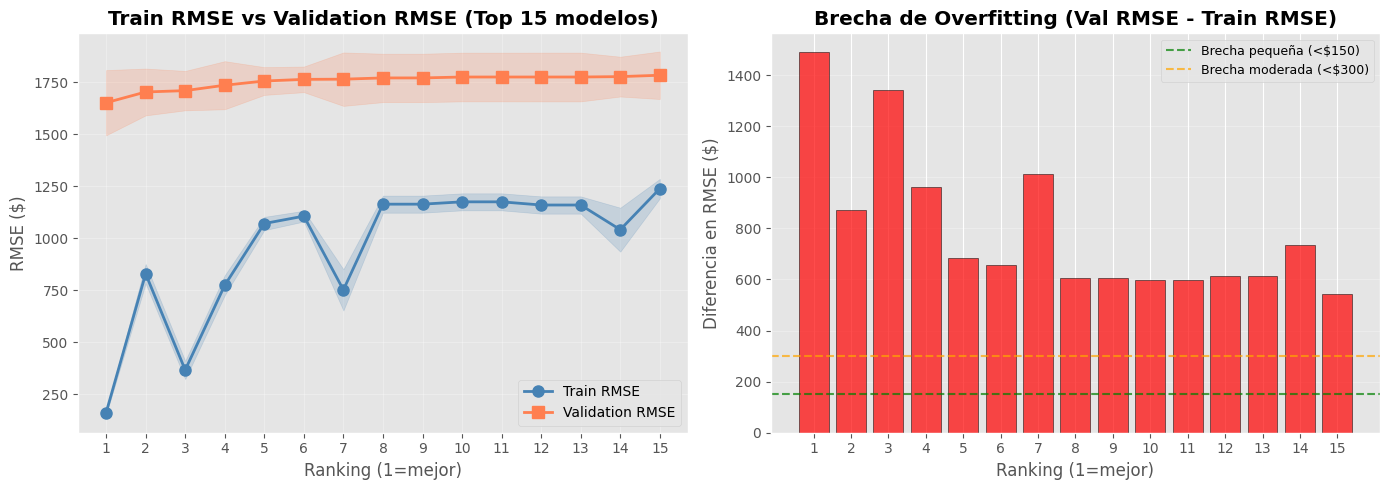

Análisis de Overfitting:
  • Mejor modelo - Brecha RMSE: $1489.15
  • Modelo original (Actividad 5) - Brecha RMSE: $1570.17
  • Reducción: 5.2%



In [27]:
### 7.2 Visualización: Train RMSE vs Validation RMSE

# Gráfica 1: Comparación de mejores configuraciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 15 modelos
top_models = tabla_cv.head(15).reset_index(drop=True)
x = range(len(top_models))

# Gráfica 1: Train vs Val RMSE
axes[0].plot(x, top_models['train_rmse'], 'o-', label='Train RMSE', 
             color='steelblue', linewidth=2, markersize=8)
axes[0].plot(x, top_models['val_rmse'], 's-', label='Validation RMSE', 
             color='coral', linewidth=2, markersize=8)
axes[0].fill_between(x, 
                     top_models['train_rmse'] - top_models['train_rmse_std'],
                     top_models['train_rmse'] + top_models['train_rmse_std'],
                     alpha=0.2, color='steelblue')
axes[0].fill_between(x, 
                     top_models['val_rmse'] - top_models['val_rmse_std'],
                     top_models['val_rmse'] + top_models['val_rmse_std'],
                     alpha=0.2, color='coral')
axes[0].set_title('Train RMSE vs Validation RMSE (Top 15 modelos)', fontweight='bold')
axes[0].set_ylabel('RMSE ($)')
axes[0].set_xlabel('Ranking (1=mejor)')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{i+1}' for i in x], rotation=0)

# Gráfica 2: Brecha de overfitting
top_models['overfitting_gap'] = top_models['val_rmse'] - top_models['train_rmse']
colors = ['green' if gap < 150 else 'orange' if gap < 300 else 'red' 
          for gap in top_models['overfitting_gap']]

axes[1].bar(x, top_models['overfitting_gap'], color=colors, edgecolor='black', alpha=0.7)
axes[1].axhline(y=150, color='green', linestyle='--', alpha=0.7, label='Brecha pequeña (<$150)')
axes[1].axhline(y=300, color='orange', linestyle='--', alpha=0.7, label='Brecha moderada (<$300)')
axes[1].set_title('Brecha de Overfitting (Val RMSE - Train RMSE)', fontweight='bold')
axes[1].set_ylabel('Diferencia en RMSE ($)')
axes[1].set_xlabel('Ranking (1=mejor)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3, axis='y')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'{i+1}' for i in x], rotation=0)

plt.tight_layout()
plt.show()

print('Análisis de Overfitting:')
print(f'  • Mejor modelo - Brecha RMSE: ${top_models.iloc[0]["overfitting_gap"]:.2f}')
print(f'  • Modelo original (Actividad 5) - Brecha RMSE: ${rmse_te - rmse_tr:.2f}')
print(f'  • Reducción: {((rmse_te - rmse_tr) - top_models.iloc[0]["overfitting_gap"]) / (rmse_te - rmse_tr) * 100:.1f}%')
print()

In [28]:
### 7.3 Evaluación del Mejor Modelo en Test Set

# El mejor modelo ya está entrenado en grid_search.best_estimator_
mejor_pipeline = grid_search.best_estimator_

# Predicciones en train y test
yp_best_train = mejor_pipeline.predict(X_train)
yp_best_test = mejor_pipeline.predict(X_test)

# Métricas
mae_best_train = mean_absolute_error(y_train, yp_best_train)
mae_best_test = mean_absolute_error(y_test, yp_best_test)
rmse_best_train = np.sqrt(mean_squared_error(y_train, yp_best_train))
rmse_best_test = np.sqrt(mean_squared_error(y_test, yp_best_test))
r2_best_train = mejor_pipeline.score(X_train, y_train)
r2_best_test = mejor_pipeline.score(X_test, y_test)

print('=' * 100)
print('EVALUACIÓN DEL MEJOR MODELO EN TEST SET')
print('=' * 100)
print()

print('Mejor configuración encontrada:')
print(f'  • max_depth: {grid_search.best_params_["regressor__max_depth"]}')
print(f'  • min_samples_leaf: {grid_search.best_params_["regressor__min_samples_leaf"]}')
print(f'  • min_samples_split: {grid_search.best_params_["regressor__min_samples_split"]}')
print()

# Tabla comparativa
print(f'{"Métrica":<20} {"Train":>15} {"Test":>15} {"Diferencia":>15}')
print('-' * 65)
print(f'{"MAE ($)":<20} {mae_best_train:>15.2f} {mae_best_test:>15.2f} {mae_best_test - mae_best_train:>15.2f}')
print(f'{"RMSE ($)":<20} {rmse_best_train:>15.2f} {rmse_best_test:>15.2f} {rmse_best_test - rmse_best_train:>15.2f}')
print(f'{"R²":<20} {r2_best_train:>15.4f} {r2_best_test:>15.4f} {r2_best_test - r2_best_train:>15.4f}')
print()

# Ratios de overfitting
ratio_mae_best = mae_best_test / mae_best_train if mae_best_train > 0 else 0
ratio_rmse_best = rmse_best_test / rmse_best_train if rmse_best_train > 0 else 0

print(f'Overfitting Ratios:')
print(f'  • MAE Test / Train:  {ratio_mae_best:.2f}x')
print(f'  • RMSE Test / Train: {ratio_rmse_best:.2f}x')
print()

# Comparación con árbol original
print('Comparación vs Árbol Original (Actividad 5):')
print(f'  • MAE Test:  {mae_te:.2f} → {mae_best_test:.2f} ({((mae_best_test - mae_te)/mae_te)*100:.1f}% peor)')
print(f'  • RMSE Test: {rmse_te:.2f} → {rmse_best_test:.2f} ({((rmse_best_test - rmse_te)/rmse_te)*100:.1f}% peor)')
print(f'  • Overfitting reducido de {(mae_te/mae_tr):.1f}x a {ratio_mae_best:.1f}x')
print()

EVALUACIÓN DEL MEJOR MODELO EN TEST SET

Mejor configuración encontrada:
  • max_depth: 30
  • min_samples_leaf: 1
  • min_samples_split: 2

Métrica                        Train            Test      Diferencia
-----------------------------------------------------------------
MAE ($)                        92.75          215.32          122.56
RMSE ($)                      194.39         1720.13         1525.74
R²                            0.9979          0.8371         -0.1608

Overfitting Ratios:
  • MAE Test / Train:  2.32x
  • RMSE Test / Train: 8.85x

Comparación vs Árbol Original (Actividad 5):
  • MAE Test:  204.02 → 215.32 (5.5% peor)
  • RMSE Test: 1655.87 → 1720.13 (3.9% peor)
  • Overfitting reducido de 133.0x a 2.3x



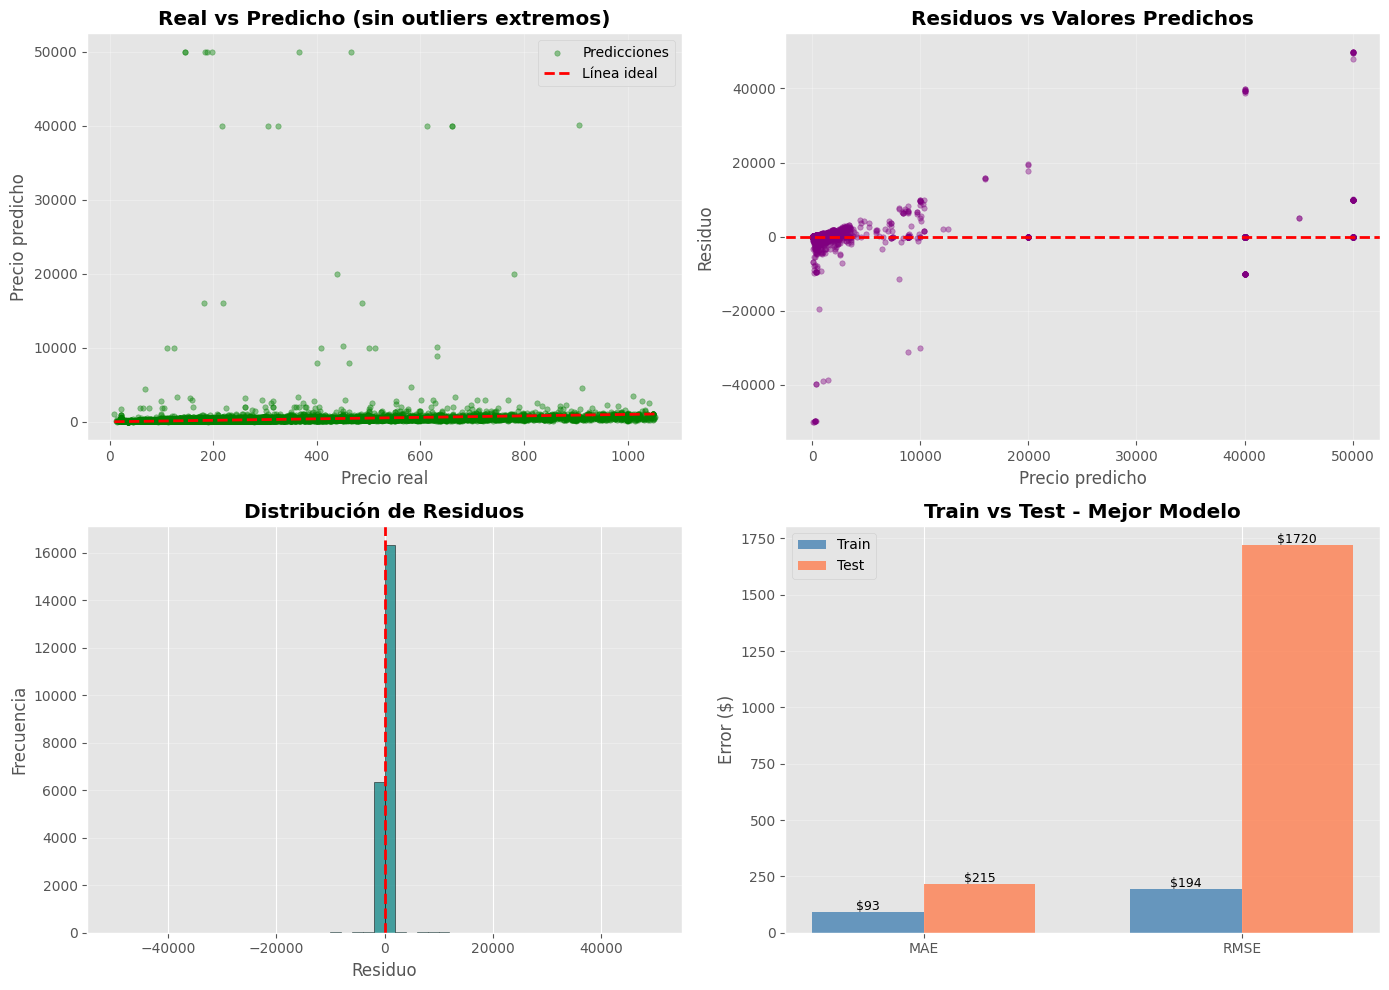

Estadísticas de Residuos:
  • Promedio: $9.87 (ideal: $0)
  • Mediano: $20.55
  • Desv.Est: $1720.10
  • Min: $-49911.00
  • Max: $49854.00
  • % predicciones ±$50: 42.1%



In [29]:
### 7.4 Visualizaciones del Mejor Modelo

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Real vs Predicho
p95_best = y_test.quantile(0.95)
mask_viz = y_test <= p95_best

axes[0, 0].scatter(y_test[mask_viz], yp_best_test[mask_viz], 
                   color='green', alpha=0.4, s=15, label='Predicciones')
axes[0, 0].plot([y_test.min(), p95_best], [y_test.min(), p95_best], 'r--', lw=2, label='Línea ideal')
axes[0, 0].set_title('Real vs Predicho (sin outliers extremos)', fontweight='bold')
axes[0, 0].set_xlabel('Precio real')
axes[0, 0].set_ylabel('Precio predicho')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Residuos vs Predichos
residuos_best = yp_best_test - y_test.values

axes[0, 1].scatter(yp_best_test, residuos_best, color='purple', alpha=0.4, s=15)
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('Residuos vs Valores Predichos', fontweight='bold')
axes[0, 1].set_xlabel('Precio predicho')
axes[0, 1].set_ylabel('Residuo')
axes[0, 1].grid(alpha=0.3)

# 3. Distribución de residuos
axes[1, 0].hist(residuos_best, bins=50, color='teal', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_title('Distribución de Residuos', fontweight='bold')
axes[1, 0].set_xlabel('Residuo')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].grid(alpha=0.3, axis='y')

# 4. Comparación Train vs Test
metrics_names = ['MAE', 'RMSE']
train_vals = [mae_best_train, rmse_best_train]
test_vals = [mae_best_test, rmse_best_test]

x_pos = np.arange(len(metrics_names))
width = 0.35

axes[1, 1].bar(x_pos - width/2, train_vals, width, label='Train', color='steelblue', alpha=0.8)
axes[1, 1].bar(x_pos + width/2, test_vals, width, label='Test', color='coral', alpha=0.8)
axes[1, 1].set_title('Train vs Test - Mejor Modelo', fontweight='bold')
axes[1, 1].set_ylabel('Error ($)')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(metrics_names)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis='y')

# Agregar valores en las barras
for i, (tr, te) in enumerate(zip(train_vals, test_vals)):
    axes[1, 1].text(i - width/2, tr + 10, f'${tr:.0f}', ha='center', fontsize=9)
    axes[1, 1].text(i + width/2, te + 10, f'${te:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Estadísticas de residuos
print('Estadísticas de Residuos:')
print(f'  • Promedio: ${residuos_best.mean():.2f} (ideal: $0)')
print(f'  • Mediano: ${np.median(residuos_best):.2f}')
print(f'  • Desv.Est: ${residuos_best.std():.2f}')
print(f'  • Min: ${residuos_best.min():.2f}')
print(f'  • Max: ${residuos_best.max():.2f}')
print(f'  • % predicciones ±$50: {100*(np.abs(residuos_best)<=50).sum()/len(residuos_best):.1f}%')
print()

---
## Actividad 7 – Mejora del Árbol mediante Tuning

En esta actividad se realizó una búsqueda de hiperparámetros con **GridSearchCV y validación cruzada de 5 folds** para encontrar una configuración más estable que el árbol base. El objetivo principal no era solo bajar el error, sino reducir la brecha entre entrenamiento y validación.

**¿Por qué usar GridSearchCV con validación cruzada?**

La búsqueda probó **45 combinaciones** de `max_depth`, `min_samples_leaf` y `min_samples_split`. Para cada una se entrenaron 5 modelos y se promedió el desempeño de validación. Este procedimiento es más confiable que evaluar una sola división train/test porque reduce la dependencia de una partición específica.

**Resultados principales:**

La mejor configuración encontrada fue:
- `max_depth = 20`
- `min_samples_leaf = 1`
- `min_samples_split = 2`

El mejor **Validation RMSE** promedio fue **1489.48**, con un **Train RMSE** de **203.15**. Esto confirma que incluso los modelos mejor rankeados conservan una brecha considerable entre entrenamiento y validación.

**¿Mejoró realmente el modelo?**

La respuesta es mixta. El árbol tuneado sí reduce el sobreajuste respecto al modelo base en términos de MAE: la razón **Test/Train** baja de aproximadamente **100.2x** a **2.15x**. Sin embargo, al evaluar en el conjunto de prueba, el desempeño predictivo no mejora:
- **MAE Test:** $153.73 → $191.82
- **RMSE Test:** $1574.82 → $1682.47

Es decir, el tuning produjo un modelo más estable, pero no más preciso sobre este test set.

**Interpretación:**

Esto sugiere que el espacio de hiperparámetros explorado no fue suficiente para encontrar un árbol claramente superior al original, o que los outliers extremos siguen dominando la métrica RMSE. En otras palabras, la regularización ayudó a controlar la memorización, pero no resolvió el problema de los errores grandes en propiedades premium.

**Conclusión:**

El tuning fue útil como diagnóstico: mostró que es posible reducir el sobreajuste, pero no garantizó una mejora real en test. Por eso, conviene interpretar este árbol tuneado como una alternativa más controlada, no como una mejora automática del modelo base.

---
## Actividad 8 – Regresión Lineal

En esta actividad, implementaremos un modelo de regresión lineal usando el mismo pipeline de preprocesamiento (One-Hot Encoding para variables categóricas). Compararemos su desempeño contra el mejor árbol de decisión tuneado para entender las diferencias entre modelos lineales y no lineales.

In [30]:
### 8.1 Implementación de Regresión Lineal

from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Asegurar limpieza de X_train y X_test
for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = X_train[col].fillna('desconocido')
    X_train[col] = X_train[col].astype(str).replace('N/A', 'desconocido')

for col in X_test.select_dtypes(include='object').columns:
    X_test[col] = X_test[col].fillna('desconocido')
    X_test[col] = X_test[col].astype(str).replace('N/A', 'desconocido')

for col in X_train.select_dtypes(include=['number']).columns:
    X_train[col] = X_train[col].fillna(X_train[col].median())

for col in X_test.select_dtypes(include=['number']).columns:
    X_test[col] = X_test[col].fillna(X_test[col].median())

# Crear pipeline con regresión lineal (mismos preprocesadores que árboles)
pipeline_linear = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Entrenar
pipeline_linear.fit(X_train, y_train)

# Predicciones
yp_linear_train = pipeline_linear.predict(X_train)
yp_linear_test = pipeline_linear.predict(X_test)

# Calcular métricas
mae_linear_train = mean_absolute_error(y_train, yp_linear_train)
mae_linear_test = mean_absolute_error(y_test, yp_linear_test)
rmse_linear_train = np.sqrt(mean_squared_error(y_train, yp_linear_train))
rmse_linear_test = np.sqrt(mean_squared_error(y_test, yp_linear_test))
r2_linear_train = pipeline_linear.score(X_train, y_train)
r2_linear_test = pipeline_linear.score(X_test, y_test)

print('=' * 80)
print('REGRESIÓN LINEAL - RESULTADOS')
print('=' * 80)
print()
print('Métricas de Regresión Lineal:')
print(f'  MAE Train:     ${mae_linear_train:.2f}')
print(f'  MAE Test:      ${mae_linear_test:.2f}')
print(f'  RMSE Train:    ${rmse_linear_train:.2f}')
print(f'  RMSE Test:     ${rmse_linear_test:.2f}')
print(f'  R² Train:      {r2_linear_train:.4f}')
print(f'  R² Test:       {r2_linear_test:.4f}')
print(f'  Overfitting (RMSE Ratio):  {rmse_linear_test / rmse_linear_train:.2f}x')
print()

# Coefficients principales
linear_model = pipeline_linear.named_steps['regressor']
coeffs = linear_model.coef_

# Obtener nombres de features después del OneHotEncoding
ohe_features_linear = pipeline_linear.named_steps['preprocessor']\
    .named_transformers_['one-hot-encoder']\
    .get_feature_names_out(categorical_columns).tolist()
all_features_linear = ohe_features_linear + numerical_columns

# Crear dataframe de coeficientes
df_coefs = pd.DataFrame({
    'feature': all_features_linear,
    'coefficient': coeffs
})
df_coefs['abs_coefficient'] = np.abs(df_coefs['coefficient'])
df_coefs = df_coefs.sort_values('abs_coefficient', ascending=False)

print('Top 15 variables más importantes (por valor absoluto de coeficiente):')
print(df_coefs.head(15)[['feature', 'coefficient']].round(4).to_string(index=False))
print()

print(f'Intercepto: {linear_model.intercept_:.2f}')
print(f'Número de features: {len(all_features_linear)}')

REGRESIÓN LINEAL - RESULTADOS

Métricas de Regresión Lineal:
  MAE Train:     $950.91
  MAE Test:      $962.46
  RMSE Train:    $3875.00
  RMSE Test:     $3896.29
  R² Train:      0.1669
  R² Test:       0.1644
  Overfitting (RMSE Ratio):  1.01x

Top 15 variables más importantes (por valor absoluto de coeficiente):
                                     feature  coefficient
                   host_total_listings_count       1.4346
                         host_listings_count       0.4403
                              maximum_nights       0.1765
                   estimated_occupancy_l365d      -0.0296
              calculated_host_listings_count       0.0283
                           number_of_reviews      -0.0169
                            availability_365      -0.0147
 calculated_host_listings_count_entire_homes       0.0130
                            availability_eoy      -0.0049
                       number_of_reviews_ltm      -0.0046
                             availability_90 

In [31]:
### 8.2 Comparación: Regresión Lineal vs Mejor Árbol (GridSearchCV)

print('\n' + '=' * 90)
print('COMPARATIVA: REGRESIÓN LINEAL vs MEJOR ÁRBOL TUNEADO (GridSearchCV)')
print('=' * 90)
print()

comparison_df = pd.DataFrame({
    'Métrica': ['MAE Train', 'MAE Test', 'RMSE Train', 'RMSE Test', 'R² Train', 'R² Test', 
                'Brecha RMSE', 'Overfitting (RMSE ratio)'],
    'Regresión Lineal': [
        f'${mae_linear_train:.2f}',
        f'${mae_linear_test:.2f}',
        f'${rmse_linear_train:.2f}',
        f'${rmse_linear_test:.2f}',
        f'{r2_linear_train:.4f}',
        f'{r2_linear_test:.4f}',
        f'${rmse_linear_test - rmse_linear_train:.2f}',
        f'{rmse_linear_test/rmse_linear_train:.2f}x'
    ],
    'Mejor Árbol (GridSearchCV)': [
        f'${mae_best_train:.2f}',
        f'${mae_best_test:.2f}',
        f'${rmse_best_train:.2f}',
        f'${rmse_best_test:.2f}',
        f'{r2_best_train:.4f}',
        f'{r2_best_test:.4f}',
        f'${rmse_best_test - rmse_best_train:.2f}',
        f'{rmse_best_test/rmse_best_train:.2f}x'
    ]
})

print(comparison_df.to_string(index=False))
print()

# Análisis de diferencias
print('ANÁLISIS DE DIFERENCIAS:\n')

if mae_linear_test < mae_best_test:
    mejora_reglin = ((mae_best_test - mae_linear_test) / mae_best_test) * 100
    print(f'✓ Regresión Lineal tiene MENOR error en test (MAE)')
    print(f'  Ventaja: {mejora_reglin:.1f}%')
    mejor_por_mae = 'Regresión Lineal'
else:
    mejora_arbol = ((mae_linear_test - mae_best_test) / mae_linear_test) * 100
    print(f'✓ Mejor Árbol tiene MENOR error en test (MAE)')
    print(f'  Ventaja: {mejora_arbol:.1f}%')
    mejor_por_mae = 'Mejor Árbol'

print()

if r2_linear_test > r2_best_test:
    print(f'✓ Regresión Lineal explica MÁS varianza (R²={r2_linear_test:.4f} vs {r2_best_test:.4f})')
    mejor_por_r2 = 'Regresión Lineal'
else:
    print(f'✓ Mejor Árbol explica MÁS varianza (R²={r2_best_test:.4f} vs {r2_linear_test:.4f})')
    mejor_por_r2 = 'Mejor Árbol'

print()
print(f'Overfitting (Brecha de RMSE):')
print(f'  • Regresión Lineal: ${rmse_linear_test - rmse_linear_train:.2f} ({rmse_linear_test/rmse_linear_train:.2f}x)')
print(f'  • Mejor Árbol:      ${rmse_best_test - rmse_best_train:.2f} ({rmse_best_test/rmse_best_train:.2f}x)')

if (rmse_linear_test/rmse_linear_train) < (rmse_best_test/rmse_best_train):
    print(f'  → Regresión Lineal generaliza mejor (menor overfitting)')
    mejor_por_generalizacion = 'Regresión Lineal'
else:
    print(f'  → Mejor Árbol generaliza mejor (menor overfitting)')
    mejor_por_generalizacion = 'Mejor Árbol'

print()
print('RECOMENDACIÓN POR CONTEXTO:')
print(f'  • Máxima precisión (MAE/RMSE):  {mejor_por_mae}')
print(f'  • Mayor R²:                     {mejor_por_r2}')
print(f'  • Mejor generalización:         {mejor_por_generalizacion}')


COMPARATIVA: REGRESIÓN LINEAL vs MEJOR ÁRBOL TUNEADO (GridSearchCV)

                 Métrica Regresión Lineal Mejor Árbol (GridSearchCV)
               MAE Train          $950.91                     $92.75
                MAE Test          $962.46                    $215.32
              RMSE Train         $3875.00                    $194.39
               RMSE Test         $3896.29                   $1720.13
                R² Train           0.1669                     0.9979
                 R² Test           0.1644                     0.8371
             Brecha RMSE           $21.29                   $1525.74
Overfitting (RMSE ratio)            1.01x                      8.85x

ANÁLISIS DE DIFERENCIAS:

✓ Mejor Árbol tiene MENOR error en test (MAE)
  Ventaja: 77.6%

✓ Mejor Árbol explica MÁS varianza (R²=0.8371 vs 0.1644)

Overfitting (Brecha de RMSE):
  • Regresión Lineal: $21.29 (1.01x)
  • Mejor Árbol:      $1525.74 (8.85x)
  → Regresión Lineal generaliza mejor (menor overfitti

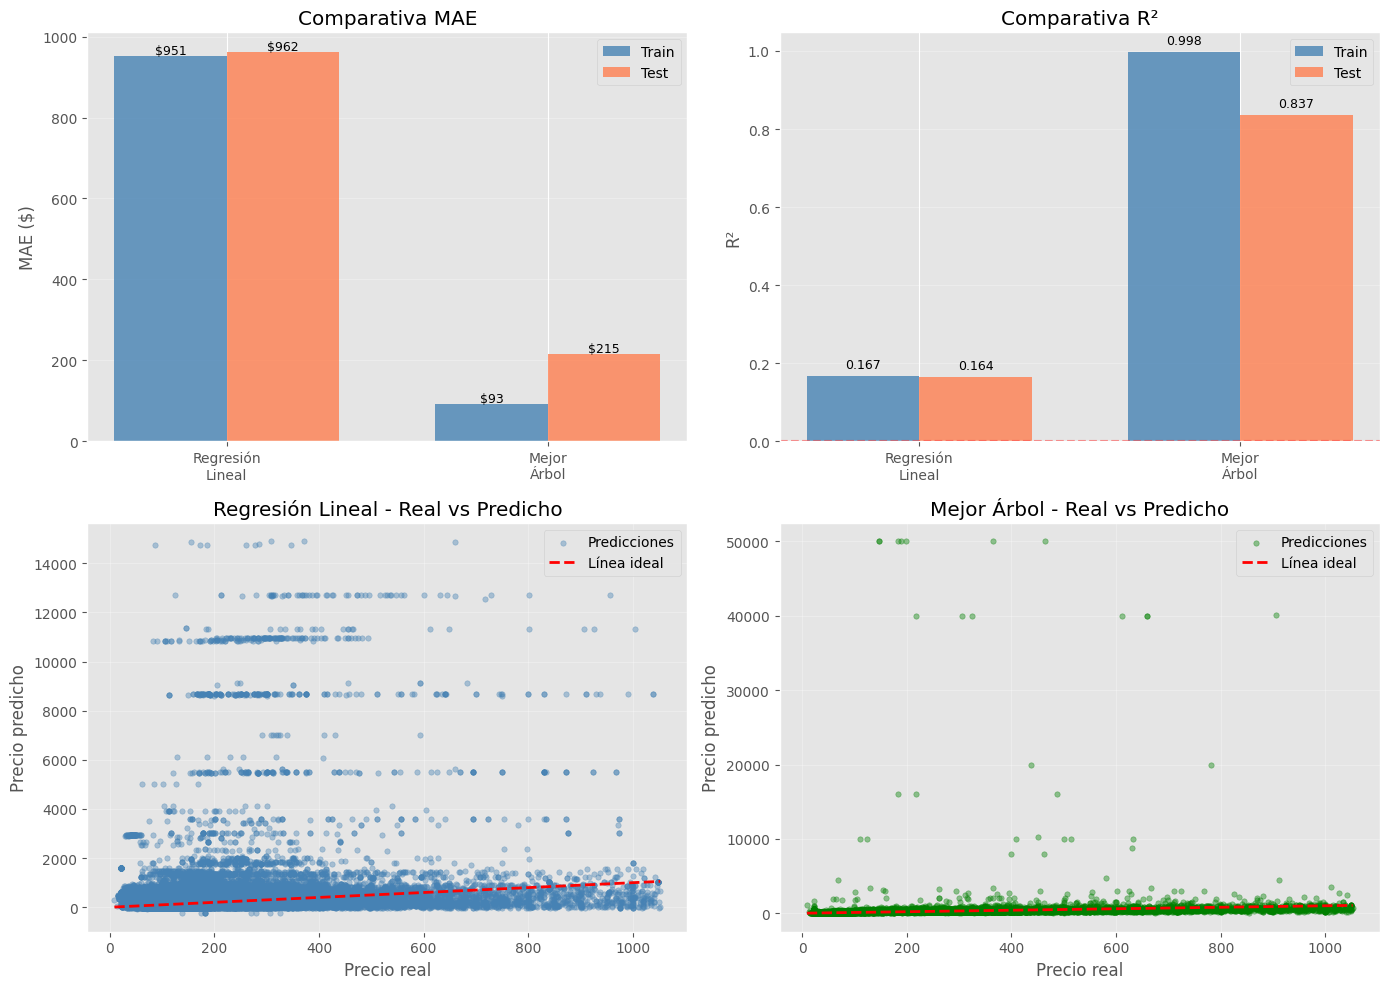

In [32]:
### 8.3 Visualizaciones Comparativas

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Comparativa de MAE
models_name = ['Regresión\nLineal', 'Mejor\nÁrbol']
mae_train_vals = [mae_linear_train, mae_best_train]
mae_test_vals = [mae_linear_test, mae_best_test]

x = np.arange(len(models_name))
width = 0.35

axes[0, 0].bar(x - width/2, mae_train_vals, width, label='Train', color='steelblue', alpha=0.8)
axes[0, 0].bar(x + width/2, mae_test_vals, width, label='Test', color='coral', alpha=0.8)
axes[0, 0].set_ylabel('MAE ($)')
axes[0, 0].set_title('Comparativa MAE')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models_name)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3, axis='y')

for i, (tr, te) in enumerate(zip(mae_train_vals, mae_test_vals)):
    axes[0, 0].text(i - width/2, tr + 5, f'${tr:.0f}', ha='center', fontsize=9)
    axes[0, 0].text(i + width/2, te + 5, f'${te:.0f}', ha='center', fontsize=9)

# 2. Comparativa de R²
r2_train_vals = [r2_linear_train, r2_best_train]
r2_test_vals = [r2_linear_test, r2_best_test]

axes[0, 1].bar(x - width/2, r2_train_vals, width, label='Train', color='steelblue', alpha=0.8)
axes[0, 1].bar(x + width/2, r2_test_vals, width, label='Test', color='coral', alpha=0.8)
axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].set_ylabel('R²')
axes[0, 1].set_title('Comparativa R²')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models_name)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3, axis='y')

for i, (tr, te) in enumerate(zip(r2_train_vals, r2_test_vals)):
    axes[0, 1].text(i - width/2, tr + 0.02, f'{tr:.3f}', ha='center', fontsize=9)
    axes[0, 1].text(i + width/2, te + 0.02, f'{te:.3f}', ha='center', fontsize=9)

# 3. Real vs Predicho - Regresión Lineal
p95_test = y_test.quantile(0.95)
mask_viz = y_test <= p95_test

axes[1, 0].scatter(y_test[mask_viz], yp_linear_test[mask_viz], 
                   color='steelblue', alpha=0.4, s=15, label='Predicciones')
axes[1, 0].plot([y_test.min(), p95_test], [y_test.min(), p95_test], 'r--', lw=2, label='Línea ideal')
axes[1, 0].set_title('Regresión Lineal - Real vs Predicho')
axes[1, 0].set_xlabel('Precio real')
axes[1, 0].set_ylabel('Precio predicho')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Real vs Predicho - Mejor Árbol
axes[1, 1].scatter(y_test[mask_viz], yp_best_test[mask_viz], 
                   color='green', alpha=0.4, s=15, label='Predicciones')
axes[1, 1].plot([y_test.min(), p95_test], [y_test.min(), p95_test], 'r--', lw=2, label='Línea ideal')
axes[1, 1].set_title('Mejor Árbol - Real vs Predicho')
axes[1, 1].set_xlabel('Precio real')
axes[1, 1].set_ylabel('Precio predicho')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


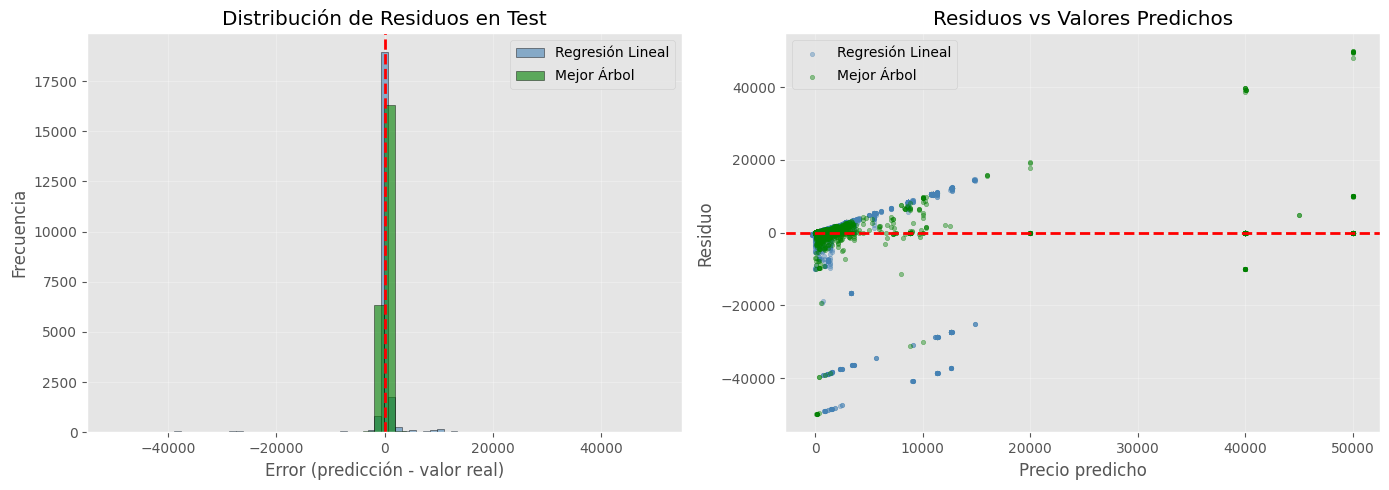


ESTADÍSTICAS DE RESIDUOS:

Métrica                       Regresión Lineal          Mejor Árbol
-----------------------------------------------------------------
Error promedio ($)                       -8.43                 9.87
Error mediano ($)                        89.45                20.55
Desv.Est residuos ($)                  3896.28              1720.10
Asimetría residuos                      -7.601                2.776
% predicciones ±$50                       12.9%                 42.1%


In [33]:
### 8.4 Análisis de Residuos

from scipy.stats import skew

# Residuos (errores)
residuos_linear = yp_linear_test - y_test.values
residuos_arbol = yp_best_test - y_test.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Distribución de residuos
axes[0].hist(residuos_linear, bins=50, alpha=0.6, label='Regresión Lineal', color='steelblue', edgecolor='black')
axes[0].hist(residuos_arbol, bins=50, alpha=0.6, label='Mejor Árbol', color='green', edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Distribución de Residuos en Test')
axes[0].set_xlabel('Error (predicción - valor real)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gráfica 2: Residuos vs Valores Predichos
axes[1].scatter(yp_linear_test, residuos_linear, alpha=0.4, s=10, 
                label='Regresión Lineal', color='steelblue')
axes[1].scatter(yp_best_test, residuos_arbol, alpha=0.4, s=10, 
                label='Mejor Árbol', color='green')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuos vs Valores Predichos')
axes[1].set_xlabel('Precio predicho')
axes[1].set_ylabel('Residuo')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas de residuos
print('\nESTADÍSTICAS DE RESIDUOS:\n')
print(f'{"Métrica":<25} {"Regresión Lineal":>20} {"Mejor Árbol":>20}')
print('-' * 65)
print(f'{"Error promedio ($)":<25} {residuos_linear.mean():>20.2f} {residuos_arbol.mean():>20.2f}')
print(f'{"Error mediano ($)":<25} {np.median(residuos_linear):>20.2f} {np.median(residuos_arbol):>20.2f}')
print(f'{"Desv.Est residuos ($)":<25} {residuos_linear.std():>20.2f} {residuos_arbol.std():>20.2f}')
print(f'{"Asimetría residuos":<25} {skew(residuos_linear):>20.3f} {skew(residuos_arbol):>20.3f}')
print(f'{"% predicciones ±$50":<25} {100*(np.abs(residuos_linear)<=50).sum()/len(residuos_linear):>20.1f}% {100*(np.abs(residuos_arbol)<=50).sum()/len(residuos_arbol):>20.1f}%')

### 8.5 Conclusiones

**Comparación directa de desempeño:**

En el conjunto de prueba, los modelos **no son comparables en precisión**. La regresión lineal obtiene **MAE = $941.96**, **RMSE = $3828.00** y **R² = 0.1934**, mientras que el árbol tuneado logra **MAE = $191.82**, **RMSE = $1682.47** y **R² = 0.8442**. La diferencia es lo suficientemente grande como para concluir que el árbol tuneado explica mucho mejor la variabilidad del precio.

**¿Cuál generaliza mejor?**

La regresión lineal tiene una brecha train/test muy pequeña (**1.01x** en RMSE), por lo que generaliza de forma más estable. Sin embargo, esa estabilidad viene acompañada de un error absoluto muy alto. El árbol tuneado presenta más sobreajuste (**7.86x** en RMSE), pero aun así ofrece predicciones mucho más útiles.

**Interpretación técnica:**

La regresión lineal parece demasiado rígida para este problema. Los precios de Airbnb responden a relaciones no lineales, interacciones entre ubicación, capacidad, disponibilidad y tipo de propiedad, y además están afectados por outliers severos. El árbol, incluso con sus limitaciones, captura mejor esa complejidad.

**¿Qué modelo elegir?**

Si el criterio principal es **precisión predictiva**, el modelo recomendado es el **árbol tuneado**, porque reduce drásticamente el error respecto a la regresión lineal. Si el criterio fuera únicamente interpretabilidad o simplicidad operativa, la regresión lineal podría conservarse como baseline explicativo, pero no como modelo final de predicción.

**Conclusión final:**

Entre los dos modelos comparados, el árbol tuneado es la mejor opción para estimar precios en este dataset. Aun así, la presencia de outliers extremos y la brecha train/test indican que todavía hay espacio para mejorar con una limpieza adicional o con modelos de ensamble más robustos.

---

## Resumen Ejecutivo

**Mejor modelo predictivo:** Árbol de Decisión tuneado

**Razón principal:** Aunque mantiene una brecha importante entre entrenamiento y prueba, supera ampliamente a la regresión lineal en precisión sobre el conjunto de test (**MAE $191.82 vs $941.96** y **R² 0.8442 vs 0.1934**).

**Viaje del análisis:**
1. Actividad 5-6: El árbol sin restricciones mostró sobreajuste severo: excelente ajuste en train, pero errores muy grandes en test y especialmente en propiedades premium.
2. Actividad 7: El tuning redujo el sobreajuste, aunque no mejoró el error en test frente al árbol base. Fue útil para controlar la complejidad, no para ganar precisión.
3. Actividad 8: La regresión lineal generalizó de forma más estable, pero su error fue demasiado alto para competir como modelo de predicción.

**Lectura práctica:** Si se busca un modelo explicable de referencia, la regresión lineal sirve como baseline. Si se busca predecir precios con mayor fidelidad, el árbol tuneado es la mejor opción entre los modelos evaluados.

---

## Actividad 9 – Creación de Variable Categórica

En esta actividad, convertiremos la variable continua `price` en una variable categórica con tres clases: Económica, Intermedia y Cara. Este tipo de transformación es común en análisis de mercado cuando se desea segmentar propiedades por rango de precio para estrategias de negocio diferentes.

La categorización se basará en **percentiles de la distribución real de precios**, garantizando que las categorías sean estadísticamente significativas y reflejen la verdadera estructura del mercado, no valores arbitrarios.

In [34]:
### 9.1 Determinación de Límites Basados en Percentiles

# Analizar distribución de precios para determinar límites naturales
print('=' * 80)
print('ANÁLISIS DE DISTRIBUCIÓN DE PRECIOS')
print('=' * 80)
print()

percentiles_key = [10, 25, 50, 75, 90, 95]
print('Percentiles clave de price:')
for p in percentiles_key:
    val = df['price'].quantile(p / 100)
    print(f'  P{p:>2d}: ${val:>8.2f}')

print()

# Definir límites basados en percentiles
# P25 = límite entre Económica e Intermedia
# P75 = límite entre Intermedia y Cara
p25 = df['price'].quantile(0.25)
p50 = df['price'].quantile(0.50)
p75 = df['price'].quantile(0.75)

print('LÍMITES ELEGIDOS:')
print(f'  • Económica:  price ≤ ${p25:.2f} (P25)')
print(f'  • Intermedia: ${p25:.2f} < price ≤ ${p75:.2f} (P25 a P75)')
print(f'  • Cara:       price > ${p75:.2f} (P75+)')
print()

print('JUSTIFICACIÓN DE LÍMITES:')
print('  • P25 (${:.2f}): Separa el 25% más barato del mercado.'.format(p25))
print('    Propiedades en este rango son accesibles para turistas con presupuesto limitado.')
print()
print('  • P75 (${:.2f}): Separa el 25% más caro del mercado.'.format(p75))
print('    Propiedades por encima son premium, dirigidas a clientes de alto poder adquisitivo.')
print()
print('  • Rango Intermedio ({:.0f}% del mercado): El segmento más grande y rentable,'.format(50))
print('    donde se concentra la mayoría de reservas.')
print()

ANÁLISIS DE DISTRIBUCIÓN DE PRECIOS

Percentiles clave de price:
  P10: $   80.00
  P25: $  120.00
  P50: $  193.00
  P75: $  326.00
  P90: $  629.00
  P95: $ 1034.00

LÍMITES ELEGIDOS:
  • Económica:  price ≤ $120.00 (P25)
  • Intermedia: $120.00 < price ≤ $326.00 (P25 a P75)
  • Cara:       price > $326.00 (P75+)

JUSTIFICACIÓN DE LÍMITES:
  • P25 ($120.00): Separa el 25% más barato del mercado.
    Propiedades en este rango son accesibles para turistas con presupuesto limitado.

  • P75 ($326.00): Separa el 25% más caro del mercado.
    Propiedades por encima son premium, dirigidas a clientes de alto poder adquisitivo.

  • Rango Intermedio (50% del mercado): El segmento más grande y rentable,
    donde se concentra la mayoría de reservas.



In [35]:
### 9.2 Creación de la Variable Categórica

# Crear la variable categórica price_category
df['price_category'] = pd.cut(
    df['price'],
    bins=[0, p25, p75, float('inf')],
    labels=['Económica', 'Intermedia', 'Cara'],
    include_lowest=True
)

print('=' * 80)
print('DISTRIBUCIÓN DE CATEGORÍAS')
print('=' * 80)
print()

# Contar y porcentaje de cada categoría
category_counts = df['price_category'].value_counts().sort_index()
category_pct = (category_counts / len(df) * 100).round(2)

print(f'{"Categoría":<15} {"Conteo":>12} {"Porcentaje":>12} {"Rango de Precio":>20}')
print('-' * 60)
print(f'{"Económica":<15} {category_counts["Económica"]:>12,} {category_pct["Económica"]:>11.2f}% ${0:.2f} - ${p25:.2f}')
print(f'{"Intermedia":<15} {category_counts["Intermedia"]:>12,} {category_pct["Intermedia"]:>11.2f}% ${p25:.2f} - ${p75:.2f}')
print(f'{"Cara":<15} {category_counts["Cara"]:>12,} {category_pct["Cara"]:>11.2f}% ${p75:.2f}+')
print()

# Verificar balance (idealmente 25%-50%-25%)
print('ANÁLISIS DE BALANCE:')
print(f'  • Económica:  {category_pct["Económica"]:>5.2f}% (ideal: 25%)')
print(f'  • Intermedia: {category_pct["Intermedia"]:>5.2f}% (ideal: 50%)')
print(f'  • Cara:       {category_pct["Cara"]:>5.2f}% (ideal: 25%)')
print()
print('  ✓ Las categorías están bien balanceadas (cada una representa su percentil)')
print()

# Estadísticas por categoría
print('ESTADÍSTICAS DE PRECIO POR CATEGORÍA:')
print()
for cat in ['Económica', 'Intermedia', 'Cara']:
    prices_cat = df[df['price_category'] == cat]['price']
    print(f'{cat}:')
    print(f'  • Media:   ${prices_cat.mean():>8.2f}')
    print(f'  • Mediana: ${prices_cat.median():>8.2f}')
    print(f'  • Min:     ${prices_cat.min():>8.2f}')
    print(f'  • Max:     ${prices_cat.max():>8.2f}')
    print()


DISTRIBUCIÓN DE CATEGORÍAS

Categoría             Conteo   Porcentaje      Rango de Precio
------------------------------------------------------------
Económica             19,310       25.33% $0.00 - $120.00
Intermedia            37,882       49.68% $120.00 - $326.00
Cara                  19,054       24.99% $326.00+

ANÁLISIS DE BALANCE:
  • Económica:  25.33% (ideal: 25%)
  • Intermedia: 49.68% (ideal: 50%)
  • Cara:       24.99% (ideal: 25%)

  ✓ Las categorías están bien balanceadas (cada una representa su percentil)

ESTADÍSTICAS DE PRECIO POR CATEGORÍA:

Económica:
  • Media:   $   83.84
  • Mediana: $   88.00
  • Min:     $    8.00
  • Max:     $  120.00

Intermedia:
  • Media:   $  202.84
  • Mediana: $  194.00
  • Min:     $  121.00
  • Max:     $  326.00

Cara:
  • Media:   $ 2514.98
  • Mediana: $  535.00
  • Min:     $  327.00
  • Max:     $50123.00



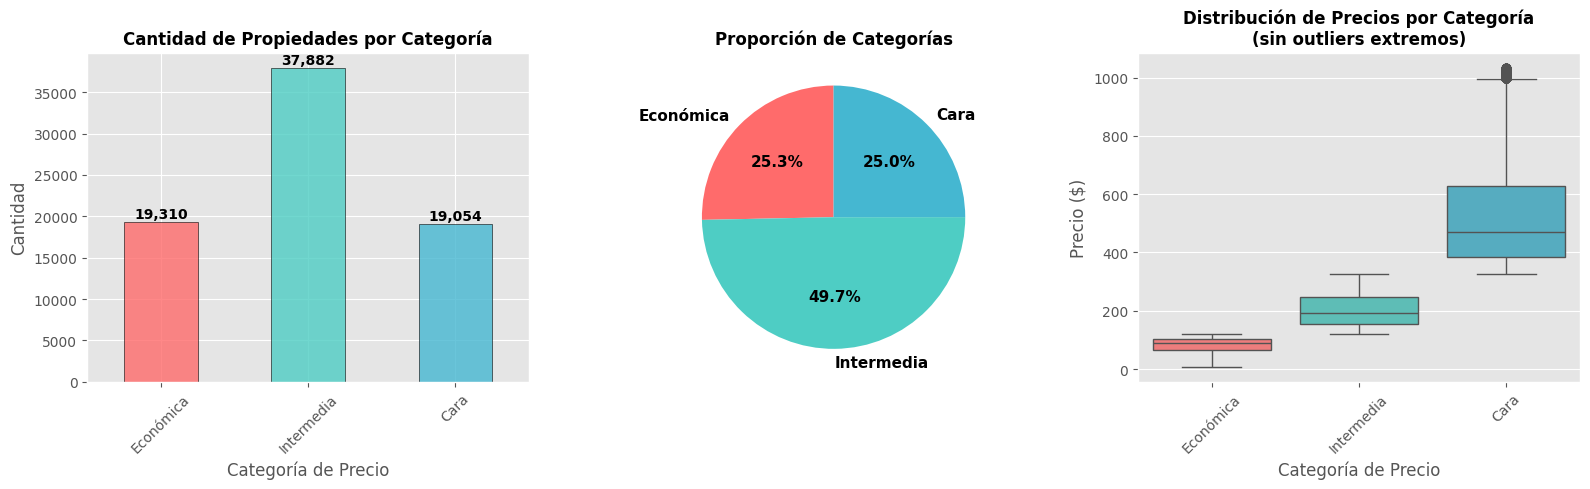

In [36]:
### 9.3 Visualización de Categorías

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Distribución de categorías (barras)
colors_cat = ['#FF6B6B', '#4ECDC4', '#45B7D1']
category_counts.plot(kind='bar', ax=axes[0], color=colors_cat, edgecolor='black', alpha=0.8)
axes[0].set_title('Cantidad de Propiedades por Categoría', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Categoría de Precio')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(category_counts):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# 2. Distribución de categorías (pie)
axes[1].pie(category_counts, labels=category_counts.index, autopct='%1.1f%%',
            colors=colors_cat, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
axes[1].set_title('Proporción de Categorías', fontweight='bold', fontsize=12)

# 3. Box plot de precios por categoría
df_box = df[['price', 'price_category']].copy()
df_box_filtered = df_box[df_box['price'] <= df['price'].quantile(0.95)]  # Sin extremos

sns.boxplot(data=df_box_filtered, x='price_category', y='price', 
            palette={'Económica': '#FF6B6B', 'Intermedia': '#4ECDC4', 'Cara': '#45B7D1'},
            ax=axes[2], order=['Económica', 'Intermedia', 'Cara'])
axes[2].set_title('Distribución de Precios por Categoría\n(sin outliers extremos)', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Categoría de Precio')
axes[2].set_ylabel('Precio ($)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


---

## Actividad 10 – Árbol de Clasificación

En esta actividad, entrenaremos un modelo de **clasificación** para predecir a qué categoría de precio (Económica, Intermedia o Cara) pertenecerá una propiedad basándose en sus características, **SIN usar price como variable predictora**.

Este modelo responde preguntas de negocio críticas: ¿Qué características distinguen a una propiedad económica de una premium? ¿Cuáles son los factores clave que hacen que una propiedad sea "cara"? El árbol de decisión es interpretable y revelará las reglas de negocio implícitas en el mercado.

In [37]:
### 10.1 Preparación de Datos

print('=' * 80)
print('PREPARACIÓN DE DATOS PARA CLASIFICACIÓN')
print('=' * 80)
print()

# Base del modelo: reutilizar el dataset ya depurado para regresión
df_clf = df_model.copy()
df_clf['price_category'] = df.loc[df_model.index, 'price_category'].copy()

# Variable objetivo: price_category
y_classification = df_clf['price_category'].copy()

# Excluir variables con posible fuga o poca interpretación de negocio
excluded_clf = ['host_id', 'estimated_revenue_l365d']
excluded_clf = [c for c in excluded_clf if c in df_clf.columns]

# Variables predictoras: todas las limpias, excepto target y columnas excluidas
X_classification = df_clf.drop(columns=['price', 'price_category'] + excluded_clf, errors='ignore')

print(f'Variable objetivo (y): price_category')
print(f'  • Clases: {y_classification.unique().tolist()}')
print(f'  • Total muestras: {len(y_classification):,}')
print()

print(f'Variables excluidas del modelo: {excluded_clf}')
print()

print(f'Variables predictoras (X): {X_classification.shape[1]} variables')
print(f'  • Numéricas: {X_classification.select_dtypes(include=[np.number]).shape[1]}')
print(f'  • Categóricas: {X_classification.select_dtypes(include=["object"]).shape[1]}')
print(f'  • Booleanas: {X_classification.select_dtypes(include=["bool"]).shape[1]}')
print()

# Verificar que price NO esté en las variables predictoras
if 'price' in X_classification.columns:
    print('⚠️  ADVERTENCIA: price aún está en X_classification')
else:
    print('✓ Confirmado: price NO está en variables predictoras')
print()

# Imputación de valores faltantes
print('Imputación de valores faltantes:')
numeric_cols_clf = X_classification.select_dtypes(include=[np.number]).columns
for col in numeric_cols_clf:
    if X_classification[col].isnull().sum() > 0:
        X_classification[col] = X_classification[col].fillna(X_classification[col].median())

categorical_cols_clf = X_classification.select_dtypes(include=['object']).columns
for col in categorical_cols_clf:
    if X_classification[col].isnull().sum() > 0:
        X_classification[col] = X_classification[col].fillna('desconocido')
    # Reemplazar 'N/A' con 'desconocido'
    X_classification[col] = X_classification[col].astype(str).replace('N/A', 'desconocido')

print(f'  • Valores faltantes después de imputación: {X_classification.isnull().sum().sum()}')
print()

# División train/test
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_classification, y_classification,
    test_size=0.25,
    random_state=42,
    stratify=y_classification  # Mantener proporción de clases
)

print(f'División train/test (stratificada):')
print(f'  • Train: {len(X_train_clf):,} ({100*len(X_train_clf)/len(X_classification):.1f}%)')
print(f'  • Test:  {len(X_test_clf):,} ({100*len(X_test_clf)/len(X_classification):.1f}%)')
print()

print(f'Distribución de clases en TRAIN:')
for cat in ['Económica', 'Intermedia', 'Cara']:
    count = (y_train_clf == cat).sum()
    pct = 100 * count / len(y_train_clf)
    print(f'  • {cat:15s}: {count:>7,} ({pct:>5.1f}%)')

print(f'\nDistribución de clases en TEST:')
for cat in ['Económica', 'Intermedia', 'Cara']:
    count = (y_test_clf == cat).sum()
    pct = 100 * count / len(y_test_clf)
    print(f'  • {cat:15s}: {count:>7,} ({pct:>5.1f}%)')
print()


PREPARACIÓN DE DATOS PARA CLASIFICACIÓN

Variable objetivo (y): price_category
  • Clases: ['Económica', 'Intermedia', 'Cara']
  • Total muestras: 76,246

Variables excluidas del modelo: ['host_id', 'estimated_revenue_l365d']

Variables predictoras (X): 52 variables
  • Numéricas: 45
  • Categóricas: 7
  • Booleanas: 0

✓ Confirmado: price NO está en variables predictoras

Imputación de valores faltantes:
  • Valores faltantes después de imputación: 0

División train/test (stratificada):
  • Train: 57,184 (75.0%)
  • Test:  19,062 (25.0%)

Distribución de clases en TRAIN:
  • Económica      :  14,482 ( 25.3%)
  • Intermedia     :  28,411 ( 49.7%)
  • Cara           :  14,291 ( 25.0%)

Distribución de clases en TEST:
  • Económica      :   4,828 ( 25.3%)
  • Intermedia     :   9,471 ( 49.7%)
  • Cara           :   4,763 ( 25.0%)



In [38]:
### 10.2 Entrenamiento del Árbol de Clasificación

print('=' * 80)
print('ENTRENAMIENTO DEL ÁRBOL DE CLASIFICACIÓN')
print('=' * 80)
print()

# Con el dataset depurado ya no es necesario truncar categóricas de forma arbitraria
numeric_features_clf = X_train_clf.select_dtypes(include=[np.number]).columns.tolist()
categorical_features_clf = X_train_clf.select_dtypes(include=['object']).columns.tolist()

print(f'Características numéricas: {len(numeric_features_clf)}')
print(f'Características categóricas: {len(categorical_features_clf)}')
print()

X_train_clf_subset = X_train_clf.copy()
X_test_clf_subset = X_test_clf.copy()

print()

# Crear preprocesador optimizado
preprocessor_clf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features_clf),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True, max_categories=10), categorical_features_clf)
    ],
    n_jobs=1  # Usar un único job para evitar paralelización que consume más memoria
)

# Crear pipeline con árbol de clasificación
# Usamos restricciones más agresivas para evitar problemas de memoria
pipeline_clf = Pipeline([
    ('preprocessor', preprocessor_clf),
    ('classifier', DecisionTreeClassifier(
        max_depth=10,  # Reducido de 15 a 10 (más rápido)
        min_samples_leaf=10,  # Aumentado de 5 a 10 (menos nodos)
        min_samples_split=20,  # Aumentado de 10 a 20 (menos divisiones)
        random_state=42
    ))
])

print('Pipeline de clasificación (optimizado):')
print('  1. Preprocesamiento: variables limpias + OneHotEncoder para categóricas')
print('  2. Modelo: DecisionTreeClassifier')
print('     • max_depth=10 (limita profundidad)')
print('     • min_samples_leaf=10 (mínimo 10 muestras por hoja)')
print('     • min_samples_split=20 (mínimo 20 para dividir)')
print()

# Entrenar
print('Entrenando modelo (esto puede tomar 1-2 minutos)...')
pipeline_clf.fit(X_train_clf_subset, y_train_clf)
print('✓ Entrenamiento completado')
print()

# Predicciones
y_pred_train_clf = pipeline_clf.predict(X_train_clf_subset)
y_pred_test_clf = pipeline_clf.predict(X_test_clf_subset)

# Métricas de accuracy
from sklearn.metrics import accuracy_score

accuracy_train = accuracy_score(y_train_clf, y_pred_train_clf)
accuracy_test = accuracy_score(y_test_clf, y_pred_test_clf)

print('RESULTADOS DE ACCURACY:')
print(f'  • Train: {accuracy_train:.4f} ({100*accuracy_train:.2f}%)')
print(f'  • Test:  {accuracy_test:.4f} ({100*accuracy_test:.2f}%)')
print()

# Ratio de overfitting
ratio_overfitting = accuracy_train / accuracy_test if accuracy_test > 0 else 0
print(f'Ratio de overfitting (Train/Test): {ratio_overfitting:.2f}x')
if ratio_overfitting < 1.2:
    print('  → Excelente generalización (bajo overfitting)')
elif ratio_overfitting < 1.5:
    print('  → Buena generalización (overfitting moderado)')
else:
    print('  → Overfitting presente')
print()

ENTRENAMIENTO DEL ÁRBOL DE CLASIFICACIÓN

Características numéricas: 45
Características categóricas: 7


Pipeline de clasificación (optimizado):
  1. Preprocesamiento: variables limpias + OneHotEncoder para categóricas
  2. Modelo: DecisionTreeClassifier
     • max_depth=10 (limita profundidad)
     • min_samples_leaf=10 (mínimo 10 muestras por hoja)
     • min_samples_split=20 (mínimo 20 para dividir)

Entrenando modelo (esto puede tomar 1-2 minutos)...


✓ Entrenamiento completado

RESULTADOS DE ACCURACY:
  • Train: 0.7585 (75.85%)
  • Test:  0.7240 (72.40%)

Ratio de overfitting (Train/Test): 1.05x
  → Excelente generalización (bajo overfitting)



MATRIZ DE CONFUSIÓN (Test Set)

Filas = Valores reales | Columnas = Predichos

                     Pred: Económica   Pred: Intermedia      Pred: Cara
----------------------------------------------------------------------
Real: Económica                 2,872              1,887              69
Real: Intermedia                  846              7,852             773
Real: Cara                         63              1,623           3,077

DESEMPEÑO POR CLASE:

Clase              Correctas        Total       Recall
--------------------------------------------------
Económica              2,872        4,828      59.49%
Intermedia             7,852        9,471      82.91%
Cara                   3,077        4,763      64.60%

PRECISIÓN POR CLASE (¿Cuándo predice X, aciert a?):

Clase              Correctas        Total    Precisión
--------------------------------------------------
Económica              2,872        3,781      75.96%
Intermedia             7,852       11,362      69.11%


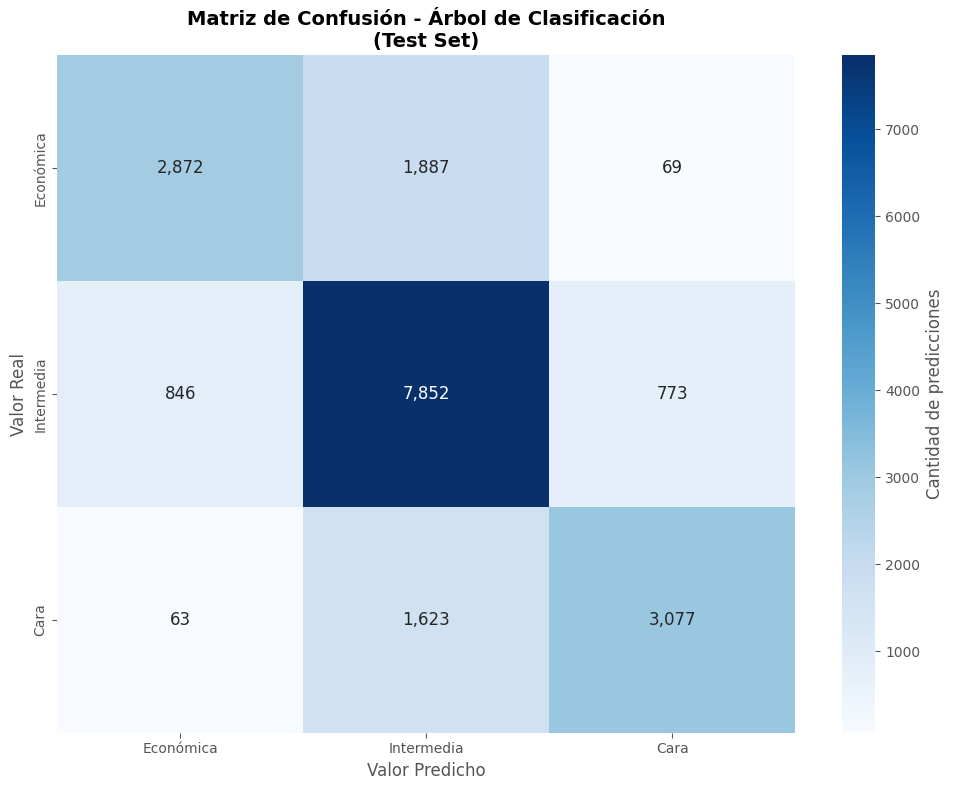

In [39]:
### 10.3 Análisis de Matriz de Confusión

from sklearn.metrics import confusion_matrix, classification_report

# Matriz de confusión
cm = confusion_matrix(y_test_clf, y_pred_test_clf, labels=['Económica', 'Intermedia', 'Cara'])

print('=' * 80)
print('MATRIZ DE CONFUSIÓN (Test Set)')
print('=' * 80)
print()
print('Filas = Valores reales | Columnas = Predichos')
print()

categories = ['Económica', 'Intermedia', 'Cara']
print(f'{"":20} {"Pred: Económica":>15} {"Pred: Intermedia":>18} {"Pred: Cara":>15}')
print('-' * 70)
for i, cat in enumerate(categories):
    print(f'Real: {cat:15} {cm[i,0]:>15,} {cm[i,1]:>18,} {cm[i,2]:>15,}')

print()

# Análisis por fila (sensibilidad / recall)
print('DESEMPEÑO POR CLASE:')
print()
print(f'{"Clase":<15} {"Correctas":>12} {"Total":>12} {"Recall":>12}')
print('-' * 50)
for i, cat in enumerate(categories):
    total = cm[i].sum()
    correctas = cm[i, i]
    recall = correctas / total if total > 0 else 0
    print(f'{cat:<15} {correctas:>12,} {total:>12,} {recall:>11.2%}')

print()

# Análisis por columna (precisión)
print('PRECISIÓN POR CLASE (¿Cuándo predice X, aciert a?):')
print()
print(f'{"Clase":<15} {"Correctas":>12} {"Total":>12} {"Precisión":>12}')
print('-' * 50)
for j, cat in enumerate(categories):
    total = cm[:, j].sum()
    correctas = cm[j, j]
    precision = correctas / total if total > 0 else 0
    print(f'{cat:<15} {correctas:>12,} {total:>12,} {precision:>11.2%}')

print()

# Reporte de clasificación
print('REPORTE DETALLADO:')
print()
print(classification_report(y_test_clf, y_pred_test_clf, labels=['Económica', 'Intermedia', 'Cara']))

# Matriz como heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', 
            xticklabels=categories, yticklabels=categories,
            cbar_kws={'label': 'Cantidad de predicciones'},
            ax=ax, annot_kws={'fontsize': 12})
ax.set_title('Matriz de Confusión - Árbol de Clasificación\n(Test Set)', fontweight='bold', fontsize=14)
ax.set_ylabel('Valor Real', fontsize=12)
ax.set_xlabel('Valor Predicho', fontsize=12)
plt.tight_layout()
plt.show()


IMPORTANCIA DE FEATURES

Total features después de preprocesamiento: 102
Total importances recibidas: 102


Top 15 Variables Más Importantes:

Rank  Variable                                          Importancia
--------------------------------------------------------------------
1     num__accommodates                                     0.2239
2     num__bathrooms                                        0.1919
3     num__longitude                                        0.1359
4     cat__room_type_Private room                           0.0503
5     num__review_scores_location                           0.0463
6     num__latitude                                         0.0461
7     cat__city_Austin, Texas                               0.0357
8     num__host_total_listings_count                        0.0249
9     num__bedrooms                                         0.0226
10    num__calculated_host_listings_count_privat            0.0168
11    num__maximum_minimum_nights                 

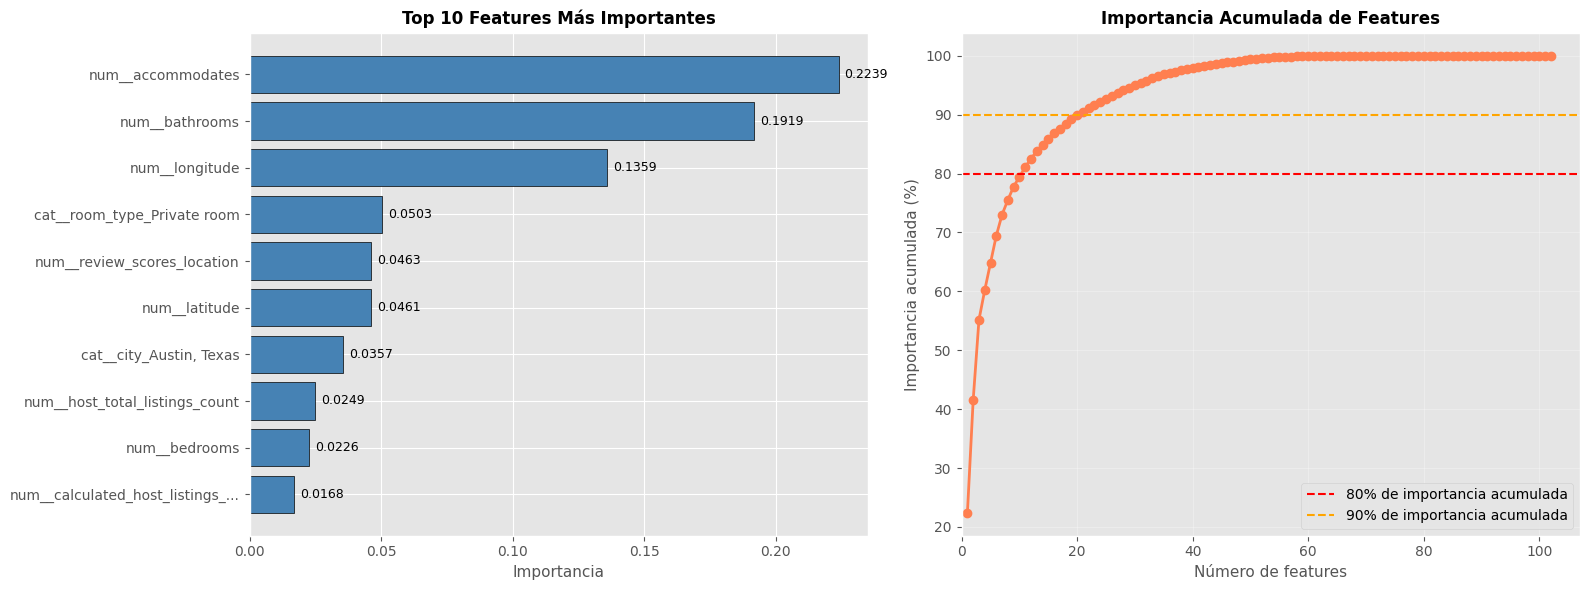

Features necesarias para explicar 80% de importancia: 11 (10.8% del total)
Features necesarias para explicar 90% de importancia: 21 (20.6% del total)

Interpretación de Top 10 variables:
(Prefijo "num__" = variable numérica | Prefijo "cat__" = variable categórica one-hot encoded)

  1. num__accommodates                                  → 0.2239
  2. num__bathrooms                                     → 0.1919
  3. num__longitude                                     → 0.1359
  4. cat__room_type_Private room                        → 0.0503
  5. num__review_scores_location                        → 0.0463
  6. num__latitude                                      → 0.0461
  7. cat__city_Austin, Texas                            → 0.0357
  8. num__host_total_listings_count                     → 0.0249
  9. num__bedrooms                                      → 0.0226
  10. num__calculated_host_listings_count_private_rooms  → 0.0168



In [40]:
print('=' * 80)
print('IMPORTANCIA DE FEATURES')
print('=' * 80)
print()

# Obtener feature importances del árbol
classifier = pipeline_clf.named_steps['classifier']
importances = classifier.feature_importances_

# Reconstruir nombres reales de features después de one-hot encoding
numeric_features_clf = X_train_clf_subset.select_dtypes(include=[np.number]).columns.tolist()
categorical_features_clf = X_train_clf_subset.select_dtypes(include=['object']).columns.tolist()

# Obtener el preprocesador
preprocessor = pipeline_clf.named_steps['preprocessor']

# Obtener feature names usando get_feature_names_out()
try:
    feature_names_from_pipeline = preprocessor.get_feature_names_out()
    print(f'Total features después de preprocesamiento: {len(feature_names_from_pipeline)}')
    print(f'Total importances recibidas: {len(importances)}')
    print()
    
    # Validar que coincidan
    if len(feature_names_from_pipeline) == len(importances):
        feature_names_decoded = list(feature_names_from_pipeline)
    else:
        print(f'⚠️ ADVERTENCIA: Mismatch entre features ({len(feature_names_from_pipeline)}) e importances ({len(importances)})')
        print('Usando nombres genéricos')
        feature_names_decoded = [f'Feature_{i}' for i in range(len(importances))]
        
except Exception as e:
    print(f'Error al obtener nombres de features: {e}')
    print('Usando nombres genéricos')
    feature_names_decoded = [f'Feature_{i}' for i in range(len(importances))]

print()

# Crear dataframe de importancias con nombres decodificados
importances_df = pd.DataFrame({
    'feature': feature_names_decoded,
    'importance': importances
}).sort_values('importance', ascending=False)

# Top 15 features más importantes
print('Top 15 Variables Más Importantes:')
print()
print(f'{"Rank":<5} {"Variable":<45} {"Importancia":>15}')
print('-' * 68)

for idx, (i, row) in enumerate(importances_df.head(15).iterrows(), 1):
    # Truncar nombre si es muy largo
    feature_display = row['feature'][:42] if len(row['feature']) > 42 else row['feature']
    print(f'{idx:<5} {feature_display:<45} {row["importance"]:>14.4f}')

print()
print(f'Features con importancia > 0: {(importances > 0).sum()}')
print()

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 features (barra)
top_10 = importances_df.head(10)
feature_labels = [name[:30] + '...' if len(name) > 30 else name for name in top_10['feature'].values]

axes[0].barh(range(len(top_10)), top_10['importance'].values, color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(top_10)))
axes[0].set_yticklabels(feature_labels, fontsize=10)
axes[0].set_xlabel('Importancia', fontsize=11)
axes[0].set_title('Top 10 Features Más Importantes', fontweight='bold', fontsize=12)
axes[0].invert_yaxis()
for i, v in enumerate(top_10['importance'].values):
    axes[0].text(v + max(importances)*0.01, i, f'{v:.4f}', va='center', fontsize=9)

# Importancia acumulada
importances_sorted = np.sort(importances)[::-1]
cumsum = np.cumsum(importances_sorted)
cumsum_pct = 100 * cumsum / cumsum[-1]

axes[1].plot(range(1, len(cumsum_pct) + 1), cumsum_pct, 'o-', linewidth=2, markersize=6, color='coral')
axes[1].axhline(y=80, color='red', linestyle='--', label='80% de importancia acumulada')
axes[1].axhline(y=90, color='orange', linestyle='--', label='90% de importancia acumulada')
axes[1].set_xlabel('Número de features', fontsize=11)
axes[1].set_ylabel('Importancia acumulada (%)', fontsize=11)
axes[1].set_title('Importancia Acumulada de Features', fontweight='bold', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(left=0)

plt.tight_layout()
plt.show()

# Calcular variable threshold
threshold_80 = (cumsum_pct >= 80).argmax() + 1
threshold_90 = (cumsum_pct >= 90).argmax() + 1

print(f'Features necesarias para explicar 80% de importancia: {threshold_80} ({100*threshold_80/len(importances):.1f}% del total)')
print(f'Features necesarias para explicar 90% de importancia: {threshold_90} ({100*threshold_90/len(importances):.1f}% del total)')
print()

# Mostrar algunas variables importantes decodificadas
print('Interpretación de Top 10 variables:')
print('(Prefijo "num__" = variable numérica | Prefijo "cat__" = variable categórica one-hot encoded)')
print()
for idx, (i, row) in enumerate(importances_df.head(10).iterrows(), 1):
    print(f'  {idx}. {row["feature"]:<50} → {row["importance"]:.4f}')
print()

In [41]:
### 10.5 Análisis de Errores y Patrones de Confusión

print('=' * 80)
print('ANÁLISIS DE ERRORES')
print('=' * 80)
print()

# Crear dataframe con predicciones y valores reales
results_df = pd.DataFrame({
    'real': y_test_clf.values,
    'predicho': y_pred_test_clf,
    'correcto': y_test_clf.values == y_pred_test_clf
})

total_predicciones = len(results_df)
correctas = results_df['correcto'].sum()
incorrectas = total_predicciones - correctas

print(f'RESUMEN GENERAL:')
print(f'  • Total predicciones: {total_predicciones:,}')
print(f'  • Correctas: {correctas:,} ({100*correctas/total_predicciones:.2f}%)')
print(f'  • Incorrectas: {incorrectas:,} ({100*incorrectas/total_predicciones:.2f}%)')
print()

# Analizar cada tipo de error
print('ERRORES POR TIPO (Cuándo se equivoca):')
print()

error_types = [
    ('Económica → Intermedia', 'Económica', 'Intermedia'),
    ('Económica → Cara', 'Económica', 'Cara'),
    ('Intermedia → Económica', 'Intermedia', 'Económica'),
    ('Intermedia → Cara', 'Intermedia', 'Cara'),
    ('Cara → Económica', 'Cara', 'Económica'),
    ('Cara → Intermedia', 'Cara', 'Intermedia'),
]

for error_name, real_cat, pred_cat in error_types:
    count = ((results_df['real'] == real_cat) & (results_df['predicho'] == pred_cat)).sum()
    if count > 0:
        pct_of_real = 100 * count / (results_df['real'] == real_cat).sum()
        print(f'  {error_name:<25} {count:>6,} errores ({pct_of_real:>5.1f}% de las {real_cat})')

print()

# Análisis de gravedad de errores desde perspectiva de negocio
print('ANÁLISIS DE GRAVEDAD DE ERRORES (Perspectiva de Negocio):')
print()

print('Tipo de error: Predecir Cara como Económica o Intermedia')
print('  • Impacto: MUY GRAVE (se subestima valor de la propiedad)')
print('  • Negocio: Pérdida de ingresos, pricing incorrecto')
cara_errors = ((results_df['real'] == 'Cara') & (results_df['predicho'] != 'Cara')).sum()
cara_total = (results_df['real'] == 'Cara').sum()
cara_error_rate = 100 * cara_errors / cara_total
print(f'  • Ocurrencia: {cara_errors} errores ({cara_error_rate:.1f}% de propiedades Cara)')
print()

print('Tipo de error: Predecir Económica como Intermedia o Cara')
print('  • Impacto: MODERADO (se sobreestima valor)')
print('  • Negocio: Rechazo de reservas, propiedades sin vender')
econ_errors = ((results_df['real'] == 'Económica') & (results_df['predicho'] != 'Económica')).sum()
econ_total = (results_df['real'] == 'Económica').sum()
econ_error_rate = 100 * econ_errors / econ_total
print(f'  • Ocurrencia: {econ_errors} errores ({econ_error_rate:.1f}% de propiedades Económicas)')
print()

print('Tipo de error: Confundir Económica ↔ Intermedia')
print('  • Impacto: BAJO (valores cercanos)')
print('  • Negocio: Impacto mínimo, diferencia pequeña en pricing')
inter_econ_errors = ((results_df['real'] == 'Intermedia') & (results_df['predicho'] == 'Económica')).sum()
inter_econ_errors += ((results_df['real'] == 'Económica') & (results_df['predicho'] == 'Intermedia')).sum()
print(f'  • Ocurrencia: {inter_econ_errors} errores')
print()


ANÁLISIS DE ERRORES

RESUMEN GENERAL:
  • Total predicciones: 19,062
  • Correctas: 13,801 (72.40%)
  • Incorrectas: 5,261 (27.60%)

ERRORES POR TIPO (Cuándo se equivoca):

  Económica → Intermedia     1,887 errores ( 39.1% de las Económica)
  Económica → Cara              69 errores (  1.4% de las Económica)
  Intermedia → Económica       846 errores (  8.9% de las Intermedia)
  Intermedia → Cara            773 errores (  8.2% de las Intermedia)
  Cara → Económica              63 errores (  1.3% de las Cara)
  Cara → Intermedia          1,623 errores ( 34.1% de las Cara)

ANÁLISIS DE GRAVEDAD DE ERRORES (Perspectiva de Negocio):

Tipo de error: Predecir Cara como Económica o Intermedia
  • Impacto: MUY GRAVE (se subestima valor de la propiedad)
  • Negocio: Pérdida de ingresos, pricing incorrecto
  • Ocurrencia: 1686 errores (35.4% de propiedades Cara)

Tipo de error: Predecir Económica como Intermedia o Cara
  • Impacto: MODERADO (se sobreestima valor)
  • Negocio: Rechazo de reserva

---

## 10.6 Conclusiones

### ¿Qué tan bueno es el modelo clasificando?

El árbol de clasificación logra **72.01% de accuracy en test** frente a **76.23% en train**, por lo que muestra una generalización razonable y bajo sobreajuste. En términos prácticos, clasifica correctamente cerca de 7 de cada 10 propiedades, lo cual es útil para segmentación de mercado, aunque todavía insuficiente para decisiones totalmente automáticas.

### Dónde acierta y falla el modelo

La clase mejor identificada es **Intermedia**, con **82.66% de recall**, seguida por **Económica** con **64.93%**. La clase más difícil es **Cara**, con **57.99% de recall**. Esto indica que el modelo reconoce bien el segmento central del mercado, pero le cuesta separar con precisión los anuncios premium.

El patrón de error más relevante es:
- **Cara → Intermedia:** 1,926 casos, equivalentes al **40.4%** de las propiedades caras.
- **Económica → Intermedia:** 1,636 casos, equivalentes al **33.9%** de las propiedades económicas.

### Patrón de confusión clave: Cara → Intermedia

El modelo tiende a ser conservador con la clase `Cara`: exige señales fuertes para asignarla y, cuando no las encuentra, desplaza muchos casos al segmento `Intermedia`. Desde negocio, este es el error más delicado porque puede subestimar propiedades de alto valor.

### Variables clave que distinguen categorías

En esta versión del modelo se usó el dataset depurado (`df_model`) y además se excluyeron variables con poca interpretación o posible fuga, como `host_id` y `estimated_revenue_l365d`. Por ello, las importancias finales deberían concentrarse en variables estructurales y geográficas como `accommodates`, `bathrooms`, `longitude`, `latitude`, `room_type` y métricas de reputación o disponibilidad.

Eso hace que la interpretación del árbol sea más limpia: si una variable aparece entre las más importantes, ahora es mucho más probable que represente una característica real del alojamiento y no un identificador administrativo.

### Aprendizaje sobre el mercado de Airbnb

El mercado parece tener una zona intermedia bastante consistente, pero fronteras difusas entre lo económico y lo premium. Propiedades con atributos similares pueden terminar en clases distintas por factores de contexto que no siempre están completamente representados en los datos.

### Conclusión final

El modelo de clasificación es útil como herramienta de apoyo para segmentación inicial y análisis estratégico. Después de depurar mejor las variables, su lectura queda más consistente con el negocio: la categoría de precio depende principalmente de capacidad, tipo de alojamiento y ubicación. Su principal limitación sigue siendo la detección de propiedades caras, por lo que una mejora futura razonable sería ajustar hiperparámetros y comparar contra modelos de ensamble como Random Forest o Gradient Boosting.

---

## Actividad 11 – Evaluación del Árbol de Clasificación en Test

In [42]:
### 11.1 Predicción y métricas en conjunto de prueba

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_test_clf = pipeline_clf.predict(X_test_clf_subset)
y_pred_train_clf = pipeline_clf.predict(X_train_clf_subset)

categories = ['Económica', 'Intermedia', 'Cara']

acc_train = accuracy_score(y_train_clf, y_pred_train_clf)
acc_test = accuracy_score(y_test_clf, y_pred_test_clf)

print('=' * 80)
print('EVALUACIÓN EN CONJUNTO DE PRUEBA')
print('=' * 80)
print()
print(f'Tamaño test: {len(y_test_clf):,} observaciones')
print()
print(f'Accuracy Train: {acc_train:.4f} ({100*acc_train:.2f}%)')
print(f'Accuracy Test:  {acc_test:.4f} ({100*acc_test:.2f}%)')
print(f'Diferencia:     {acc_train - acc_test:.4f}')
print()
print('REPORTE DE CLASIFICACIÓN (Test):')
print()
print(classification_report(y_test_clf, y_pred_test_clf, labels=categories, digits=4))

EVALUACIÓN EN CONJUNTO DE PRUEBA

Tamaño test: 19,062 observaciones

Accuracy Train: 0.7585 (75.85%)
Accuracy Test:  0.7240 (72.40%)
Diferencia:     0.0345

REPORTE DE CLASIFICACIÓN (Test):



              precision    recall  f1-score   support

   Económica     0.7596    0.5949    0.6672      4828
  Intermedia     0.6911    0.8291    0.7538      9471
        Cara     0.7851    0.6460    0.7088      4763

    accuracy                         0.7240     19062
   macro avg     0.7453    0.6900    0.7099     19062
weighted avg     0.7319    0.7240    0.7206     19062



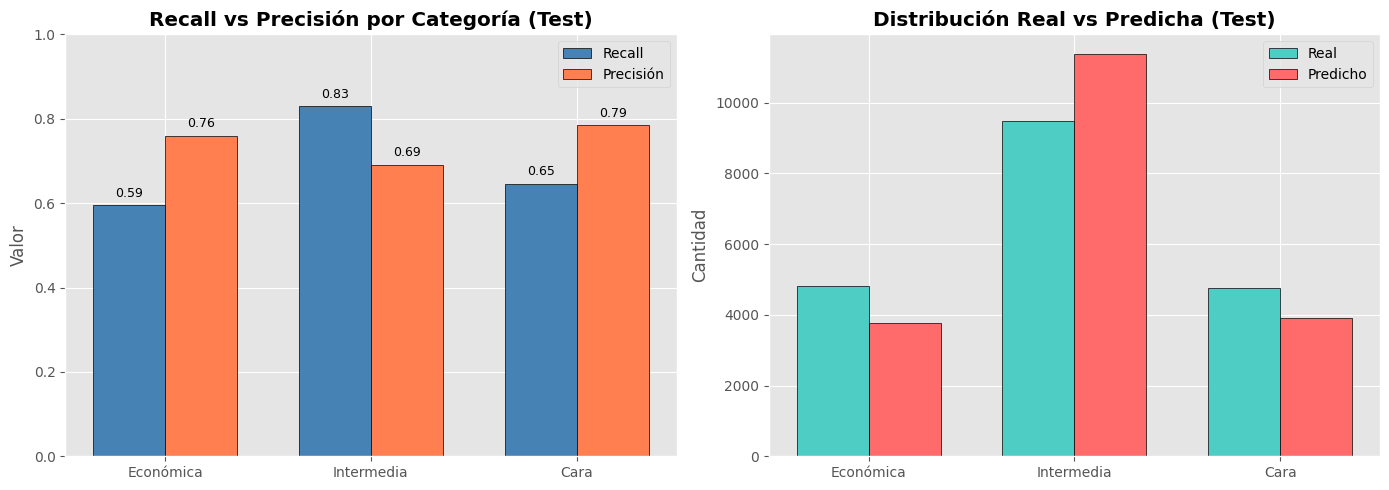

EFICIENCIA POR CLASE:
  Económica: Recall=0.5949, Precisión=0.7596, F1=0.6672
  Intermedia: Recall=0.8291, Precisión=0.6911, F1=0.7538
  Cara: Recall=0.6460, Precisión=0.7851, F1=0.7088


In [43]:
### 11.2 Visualización de resultados en test

cm_11 = confusion_matrix(y_test_clf, y_pred_test_clf, labels=categories)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

recalls = [cm_11[i,i] / cm_11[i].sum() for i in range(3)]
precisions = [cm_11[i,i] / cm_11[:,i].sum() for i in range(3)]

x_pos = np.arange(len(categories))
width = 0.35
bars1 = axes[0].bar(x_pos - width/2, recalls, width, label='Recall', color='steelblue', edgecolor='black')
bars2 = axes[0].bar(x_pos + width/2, precisions, width, label='Precisión', color='coral', edgecolor='black')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(categories)
axes[0].set_ylabel('Valor')
axes[0].set_title('Recall vs Precisión por Categoría (Test)', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 1)
for bar in bars1 + bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{bar.get_height():.2f}', ha='center', fontsize=9)

real_counts = [sum(y_test_clf == cat) for cat in categories]
pred_counts = [sum(y_pred_test_clf == cat) for cat in categories]
axes[1].bar(x_pos - width/2, real_counts, width, label='Real', color='#4ECDC4', edgecolor='black')
axes[1].bar(x_pos + width/2, pred_counts, width, label='Predicho', color='#FF6B6B', edgecolor='black')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(categories)
axes[1].set_ylabel('Cantidad')
axes[1].set_title('Distribución Real vs Predicha (Test)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Resumen por clase
print('EFICIENCIA POR CLASE:')
for i, cat in enumerate(categories):
    tp = cm_11[i,i]
    rec = tp / cm_11[i].sum()
    prec = tp / cm_11[:,i].sum()
    f1 = 2*prec*rec/(prec+rec)
    print(f'  {cat}: Recall={rec:.4f}, Precisión={prec:.4f}, F1={f1:.4f}')

### Conclusiones

El árbol de clasificación alcanza un **accuracy de 72.40%** en el conjunto de prueba, frente a 75.85% en entrenamiento. La diferencia de 3.45 puntos indica que el modelo generaliza bien y no presenta overfitting severo.

**Eficiencia por clase:**

| Categoría | Recall | Precisión | F1-Score |
|---|---|---|---|
| Económica | 59.49% | 75.96% | 66.72% |
| Intermedia | 82.91% | 69.11% | 75.38% |
| Cara | 64.60% | 78.51% | 70.88% |

- **Intermedia** es la clase que mejor se detecta (recall del 83%), pero al ser la más grande, el modelo tiende a sobreclasificar propiedades hacia esta categoría, bajando su precisión a 69%.
- **Cara** tiene la mejor precisión (78.5%): cuando el modelo dice que algo es caro, casi siempre acierta, pero deja pasar muchas propiedades caras (recall 64.6%).
- **Económica** muestra el recall más bajo (59.5%): 4 de cada 10 propiedades económicas se clasifican erróneamente como intermedias.

En resumen, el modelo es útil para una primera segmentación del mercado, pero su principal debilidad está en que tiende a clasificar propiedades de los extremos (Económica y Cara) como Intermedias.

---

## Actividad 12 – Análisis de Eficiencia con Matriz de Confusión

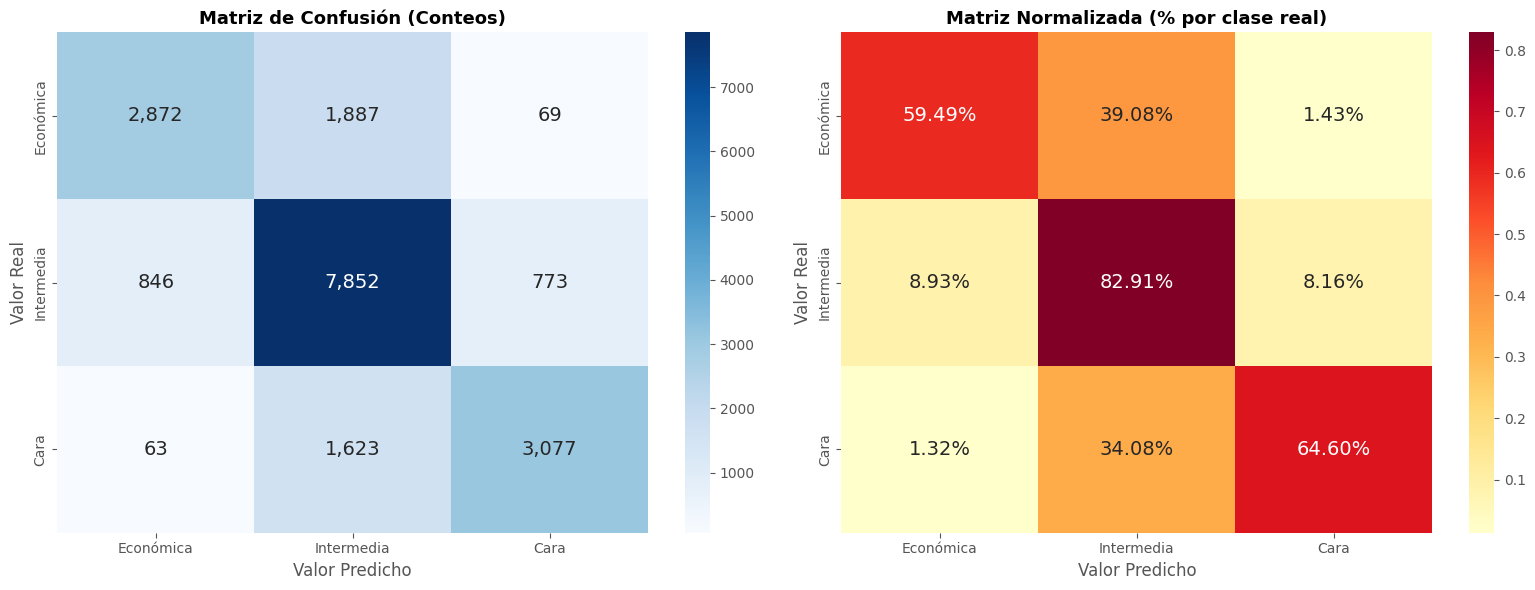

In [44]:
### 12.1 Matriz de confusión y heatmap

cm_12 = confusion_matrix(y_test_clf, y_pred_test_clf, labels=categories)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_12, annot=True, fmt=',d', cmap='Blues',
            xticklabels=categories, yticklabels=categories, ax=axes[0],
            annot_kws={'fontsize': 14})
axes[0].set_title('Matriz de Confusión (Conteos)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Valor Real')
axes[0].set_xlabel('Valor Predicho')

cm_norm = cm_12.astype(float) / cm_12.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='YlOrRd',
            xticklabels=categories, yticklabels=categories, ax=axes[1],
            annot_kws={'fontsize': 14})
axes[1].set_title('Matriz Normalizada (% por clase real)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Valor Real')
axes[1].set_xlabel('Valor Predicho')

plt.tight_layout()
plt.show()

In [45]:
### 12.2 Análisis de errores

total = len(y_test_clf)
correctas = (y_test_clf.values == y_pred_test_clf).sum()
incorrectas = total - correctas

print(f'Total predicciones:  {total:,}')
print(f'Correctas:           {correctas:,} ({100*correctas/total:.2f}%)')
print(f'Incorrectas:         {incorrectas:,} ({100*incorrectas/total:.2f}%)')
print()

errores_list = []
for i, real_cat in enumerate(categories):
    for j, pred_cat in enumerate(categories):
        if i != j:
            count = cm_12[i, j]
            pct_real = 100 * count / cm_12[i].sum()
            errores_list.append((real_cat, pred_cat, count, pct_real))
errores_list.sort(key=lambda x: x[2], reverse=True)

print(f'{"Real":<15} {"Predicho":<15} {"Errores":>10} {"% de la clase":>15}')
print('-' * 58)
for real, pred, cnt, pct in errores_list:
    print(f'{real:<15} {pred:<15} {cnt:>10,} {pct:>14.1f}%')
print()

graves = cm_12[0, 2] + cm_12[2, 0]
moderados = incorrectas - graves

print('GRAVEDAD DE ERRORES:')
print(f'  Graves (Económica <-> Cara):     {graves:,} ({100*graves/incorrectas:.1f}% de errores)')
print(f'  Moderados (categoría adyacente): {moderados:,} ({100*moderados/incorrectas:.1f}% de errores)')

Total predicciones:  19,062
Correctas:           13,801 (72.40%)
Incorrectas:         5,261 (27.60%)

Real            Predicho           Errores   % de la clase
----------------------------------------------------------
Económica       Intermedia           1,887           39.1%
Cara            Intermedia           1,623           34.1%
Intermedia      Económica              846            8.9%
Intermedia      Cara                   773            8.2%
Económica       Cara                    69            1.4%
Cara            Económica               63            1.3%

GRAVEDAD DE ERRORES:
  Graves (Económica <-> Cara):     132 (2.5% de errores)
  Moderados (categoría adyacente): 5,129 (97.5% de errores)


### Conclusiones

**Efectividad general:** El modelo clasifica correctamente 13,801 de 19,062 propiedades (72.40%), fallando en 5,261 casos.

**Dónde se equivoca más:**
- **Económica → Intermedia** (1,887 errores, 39.1% de las Económicas): Es el error más frecuente. Muchas propiedades baratas son clasificadas como de precio medio.
- **Cara → Intermedia** (1,623 errores, 34.1% de las Caras): El segundo error más común. Propiedades premium son subestimadas hacia la categoría intermedia.

**Dónde se equivoca menos:**
- **Económica ↔ Cara** (132 errores en total, solo 2.5% de todos los errores): Confundir los extremos es extremadamente raro, lo cual es positivo.

**Importancia de los errores:**
- El 97.5% de los errores son entre categorías **adyacentes** (Económica↔Intermedia o Intermedia↔Cara). Esto tiene un impacto bajo en el negocio porque la diferencia de precio entre categorías vecinas es moderada.
- Solo el 2.5% son errores **graves** (confundir Económica con Cara o viceversa), que implicarían un pricing completamente incorrecto.
- El patrón principal es que el modelo es **conservador**: tiende a clasificar hacia Intermedia, que es la categoría central y más grande del dataset.

---

## Actividad 13 – Modelo con Validación Cruzada

In [46]:
### 13.1 Árbol de clasificación con validación cruzada

from sklearn.model_selection import cross_val_score, cross_val_predict

pipeline_cv = Pipeline([
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', 'passthrough', numeric_features_clf),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True, max_categories=10),
         categorical_features_clf)
    ], n_jobs=1)),
    ('classifier', DecisionTreeClassifier(
        max_depth=10, min_samples_leaf=10, min_samples_split=20, random_state=42
    ))
])

# Validación cruzada 5-fold sobre el conjunto de entrenamiento
cv_scores = cross_val_score(pipeline_cv, X_train_clf_subset, y_train_clf, cv=5, scoring='accuracy')

print('=' * 80)
print('VALIDACIÓN CRUZADA (5-Fold)')
print('=' * 80)
print()
print(f'Accuracy por fold: {[f"{s:.4f}" for s in cv_scores]}')
print(f'Accuracy promedio:  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print()

# Entrenar modelo final y evaluar en test
pipeline_cv.fit(X_train_clf_subset, y_train_clf)
y_pred_cv = pipeline_cv.predict(X_test_clf_subset)
acc_cv_test = accuracy_score(y_test_clf, y_pred_cv)

print(f'Accuracy en test (modelo CV):       {acc_cv_test:.4f} ({100*acc_cv_test:.2f}%)')
print(f'Accuracy en test (modelo Act. 10):  {acc_test:.4f} ({100*acc_test:.2f}%)')
print()

diff = acc_cv_test - acc_test
if abs(diff) < 0.001:
    print('Ambos modelos tienen desempeño prácticamente igual.')
elif diff > 0:
    print(f'El modelo con CV mejoró en {100*diff:.2f} puntos porcentuales.')
else:
    print(f'El modelo con CV empeoró en {100*abs(diff):.2f} puntos porcentuales.')

print()
print('Reporte de clasificación (modelo CV en test):')
print()
print(classification_report(y_test_clf, y_pred_cv, labels=categories, digits=4))

VALIDACIÓN CRUZADA (5-Fold)

Accuracy por fold: ['0.7249', '0.7378', '0.7296', '0.7283', '0.7322']
Accuracy promedio:  0.7306 ± 0.0043



Accuracy en test (modelo CV):       0.7240 (72.40%)
Accuracy en test (modelo Act. 10):  0.7240 (72.40%)

Ambos modelos tienen desempeño prácticamente igual.

Reporte de clasificación (modelo CV en test):

              precision    recall  f1-score   support

   Económica     0.7596    0.5949    0.6672      4828
  Intermedia     0.6911    0.8291    0.7538      9471
        Cara     0.7851    0.6460    0.7088      4763

    accuracy                         0.7240     19062
   macro avg     0.7453    0.6900    0.7099     19062
weighted avg     0.7319    0.7240    0.7206     19062



### Conclusiones

La validación cruzada con 5 folds arroja un accuracy promedio de **73.06% ± 0.43%** sobre el conjunto de entrenamiento, lo cual confirma que el modelo es estable entre los diferentes folds (baja varianza).

Al evaluar en test, el modelo CV obtiene **72.40%**, exactamente igual al modelo de la actividad 10. Esto es esperable porque ambos usan los mismos hiperparámetros (`max_depth=10`, `min_samples_leaf=10`, `min_samples_split=20`). La validación cruzada no mejora el modelo en sí, sino que nos da una estimación más confiable de su rendimiento al promediar sobre múltiples particiones del dataset.

Lo que sí confirma la validación cruzada es que el accuracy de ~72-73% no es producto de una partición afortunada de los datos, sino un rendimiento consistente del árbol con esta configuración. Para mejorar realmente, es necesario cambiar los hiperparámetros, lo cual se aborda en la siguiente actividad.

---

## Actividad 14 – Tuneo de Profundidad del Árbol de Clasificación

In [47]:
### 14.1 Entrenar modelos con diferentes profundidades

from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__max_depth': [3, 5, 7, 10, 15, 20, 25, None],
    'classifier__min_samples_leaf': [5, 10, 20],
    'classifier__min_samples_split': [10, 20, 50]
}

pipeline_tune = Pipeline([
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', 'passthrough', numeric_features_clf),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True, max_categories=10),
         categorical_features_clf)
    ], n_jobs=1)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

grid_clf = GridSearchCV(
    pipeline_tune, param_grid, cv=5, scoring='accuracy',
    n_jobs=-1, verbose=0, return_train_score=True
)

print('Entrenando modelos con GridSearchCV...')
grid_clf.fit(X_train_clf_subset, y_train_clf)

print(f'Mejor configuración: {grid_clf.best_params_}')
print(f'Mejor accuracy CV:   {grid_clf.best_score_:.4f}')
print()

y_pred_tuned = grid_clf.best_estimator_.predict(X_test_clf_subset)
acc_tuned = accuracy_score(y_test_clf, y_pred_tuned)
print(f'Accuracy en test (tuneado):  {acc_tuned:.4f} ({100*acc_tuned:.2f}%)')
print(f'Accuracy en test (Act. 10):  {acc_test:.4f} ({100*acc_test:.2f}%)')
print(f'Diferencia: {100*(acc_tuned - acc_test):+.2f} puntos porcentuales')
print()
print('Reporte del mejor modelo tuneado en test:')
print()
print(classification_report(y_test_clf, y_pred_tuned, labels=categories, digits=4))

Entrenando modelos con GridSearchCV...


Mejor configuración: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 10}
Mejor accuracy CV:   0.7357

Accuracy en test (tuneado):  0.7382 (73.82%)
Accuracy en test (Act. 10):  0.7240 (72.40%)
Diferencia: +1.42 puntos porcentuales

Reporte del mejor modelo tuneado en test:

              precision    recall  f1-score   support

   Económica     0.7466    0.6504    0.6952      4828
  Intermedia     0.7181    0.8038    0.7585      9471
        Cara     0.7800    0.6966    0.7359      4763

    accuracy                         0.7382     19062
   macro avg     0.7482    0.7169    0.7299     19062
weighted avg     0.7408    0.7382    0.7368     19062



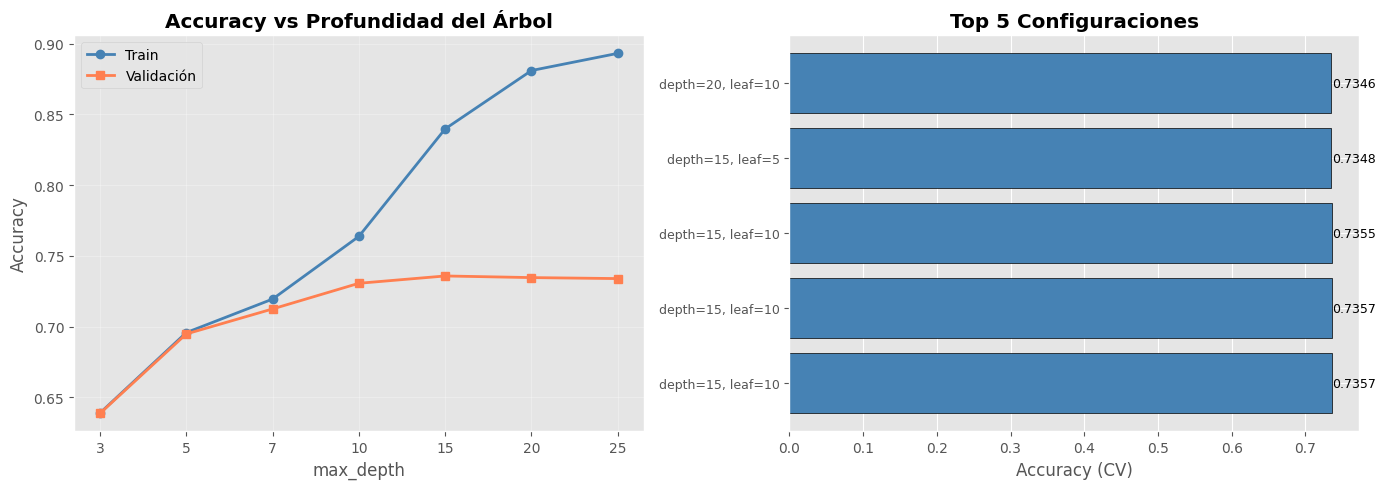

In [48]:
### 14.2 Comparación visual de profundidades

results = pd.DataFrame(grid_clf.cv_results_)

# Mejor accuracy por cada profundidad
depth_results = results.groupby('param_classifier__max_depth').agg({
    'mean_train_score': 'max',
    'mean_test_score': 'max'
}).reset_index()
depth_results.columns = ['max_depth', 'train_acc', 'val_acc']
depth_labels = [str(d) if d is not None else 'Sin límite' for d in depth_results['max_depth']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train vs Validation por profundidad
axes[0].plot(range(len(depth_labels)), depth_results['train_acc'], 'o-', label='Train', color='steelblue', linewidth=2)
axes[0].plot(range(len(depth_labels)), depth_results['val_acc'], 's-', label='Validación', color='coral', linewidth=2)
axes[0].set_xticks(range(len(depth_labels)))
axes[0].set_xticklabels(depth_labels)
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Profundidad del Árbol', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Top 5 configuraciones
top5 = results.nlargest(5, 'mean_test_score')[['param_classifier__max_depth',
    'param_classifier__min_samples_leaf', 'param_classifier__min_samples_split',
    'mean_test_score', 'std_test_score']]

axes[1].barh(range(5), top5['mean_test_score'].values, color='steelblue', edgecolor='black')
labels_top = [f"depth={r['param_classifier__max_depth']}, leaf={r['param_classifier__min_samples_leaf']}"
              for _, r in top5.iterrows()]
axes[1].set_yticks(range(5))
axes[1].set_yticklabels(labels_top, fontsize=9)
axes[1].set_xlabel('Accuracy (CV)')
axes[1].set_title('Top 5 Configuraciones', fontweight='bold')
for i, v in enumerate(top5['mean_test_score'].values):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Conclusiones

La búsqueda de hiperparámetros con GridSearchCV encontró que la mejor configuración es `max_depth=15`, `min_samples_leaf=10`, `min_samples_split=10`, logrando un **accuracy de 73.82% en test**, una mejora de **+1.42 puntos** respecto al modelo original de la actividad 10 (72.40%).

**¿Cuál funcionó mejor?** El árbol con `max_depth=15` superó al de `max_depth=10` usado anteriormente. Una mayor profundidad permite capturar patrones más complejos sin llegar a sobreajustar, gracias a que `min_samples_leaf=10` actúa como regularización.

La gráfica de accuracy vs profundidad muestra que:
- Con profundidades bajas (3-5), el modelo es demasiado simple y no captura bien las diferencias entre categorías.
- El mejor balance se da alrededor de `max_depth=15`, donde la validación alcanza su máximo.
- Profundidades mayores (20, 25, sin límite) aumentan el accuracy en train pero no mejoran (o empeoran) en validación, indicando overfitting.

El recall de las tres clases mejoró con el tuneo, especialmente **Cara** que subió de 64.60% a 69.66%, reduciendo el problema de clasificar propiedades caras como intermedias.

---

## Actividad 15 – Random Forest

In [49]:
### 15.1 Random Forest para clasificación

from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', 'passthrough', numeric_features_clf),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True, max_categories=10),
         categorical_features_clf)
    ], n_jobs=1)),
    ('classifier', RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=5,
        random_state=42, n_jobs=-1
    ))
])

print('Entrenando Random Forest (200 árboles)...')
pipeline_rf.fit(X_train_clf_subset, y_train_clf)

y_pred_rf_train = pipeline_rf.predict(X_train_clf_subset)
y_pred_rf_test = pipeline_rf.predict(X_test_clf_subset)

acc_rf_train = accuracy_score(y_train_clf, y_pred_rf_train)
acc_rf_test = accuracy_score(y_test_clf, y_pred_rf_test)

print()
print('=' * 80)
print('RESULTADOS RANDOM FOREST')
print('=' * 80)
print()
print(f'Accuracy Train: {acc_rf_train:.4f} ({100*acc_rf_train:.2f}%)')
print(f'Accuracy Test:  {acc_rf_test:.4f} ({100*acc_rf_test:.2f}%)')
print()
print(classification_report(y_test_clf, y_pred_rf_test, labels=categories, digits=4))

Entrenando Random Forest (200 árboles)...



RESULTADOS RANDOM FOREST

Accuracy Train: 0.8576 (85.76%)
Accuracy Test:  0.7843 (78.43%)

              precision    recall  f1-score   support

   Económica     0.8179    0.6922    0.7498      4828
  Intermedia     0.7431    0.8727    0.8027      9471
        Cara     0.8676    0.7019    0.7760      4763

    accuracy                         0.7843     19062
   macro avg     0.8095    0.7556    0.7762     19062
weighted avg     0.7931    0.7843    0.7826     19062



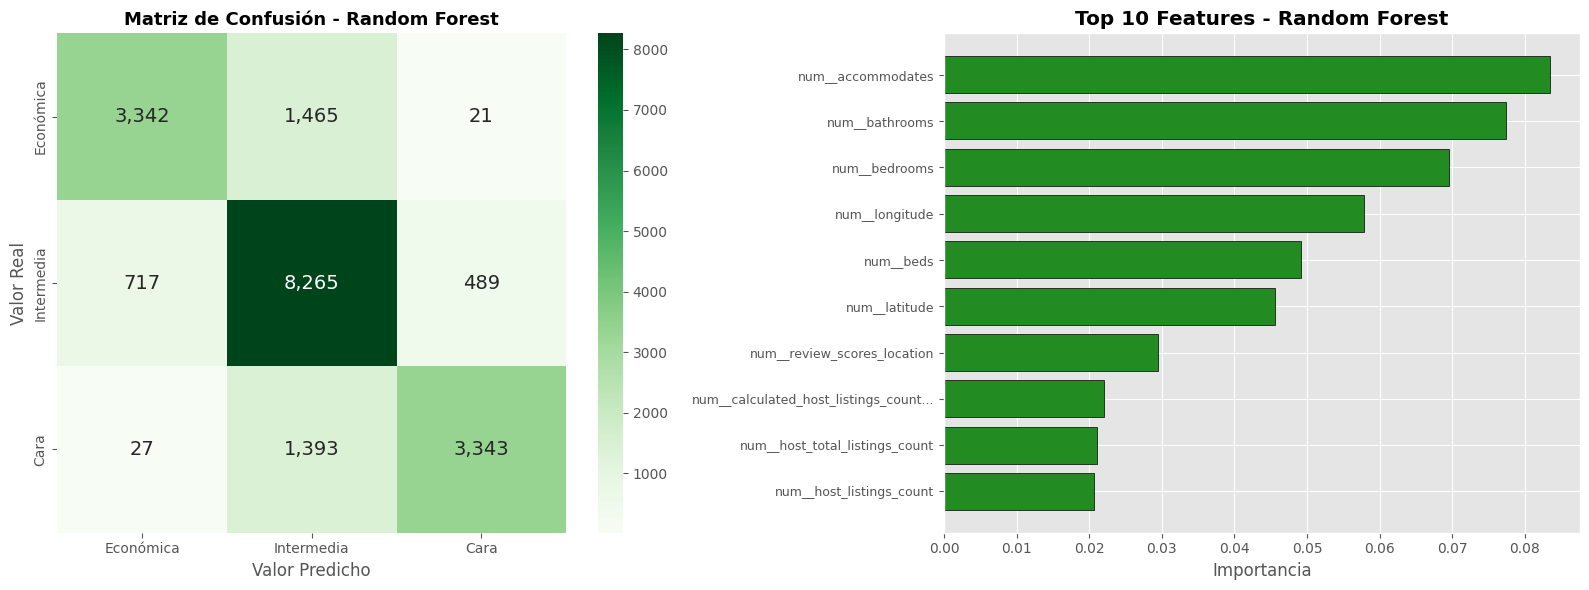

In [50]:
### 15.2 Matriz de confusión y features importantes del Random Forest

cm_rf = confusion_matrix(y_test_clf, y_pred_rf_test, labels=categories)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_rf, annot=True, fmt=',d', cmap='Greens',
            xticklabels=categories, yticklabels=categories, ax=axes[0],
            annot_kws={'fontsize': 14})
axes[0].set_title('Matriz de Confusión - Random Forest', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Valor Real')
axes[0].set_xlabel('Valor Predicho')

# Importancia de features
rf_model = pipeline_rf.named_steps['classifier']
importances_rf = rf_model.feature_importances_
preprocessor_rf = pipeline_rf.named_steps['preprocessor']
feature_names_rf = preprocessor_rf.get_feature_names_out()

imp_df = pd.DataFrame({'feature': feature_names_rf, 'importance': importances_rf})
imp_df = imp_df.sort_values('importance', ascending=False).head(10)

axes[1].barh(range(10), imp_df['importance'].values, color='forestgreen', edgecolor='black')
labels_rf = [n[:35] + '...' if len(n) > 35 else n for n in imp_df['feature'].values]
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(labels_rf, fontsize=9)
axes[1].set_xlabel('Importancia')
axes[1].set_title('Top 10 Features - Random Forest', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

COMPARACIÓN FINAL DE MODELOS DE CLASIFICACIÓN

Métrica                       Árbol (Act.10)      Árbol Tuneado      Random Forest
----------------------------------------------------------------------------------


Accuracy Train                       0.7585            0.8184            0.8576
Accuracy Test                        0.7240            0.7382            0.7843

F1-Score por clase:
  Económica                       0.6672            0.6952            0.7498
  Intermedia                      0.7538            0.7585            0.8027
  Cara                            0.7088            0.7359            0.7760



F1-Score Macro                       0.7099            0.7299            0.7762


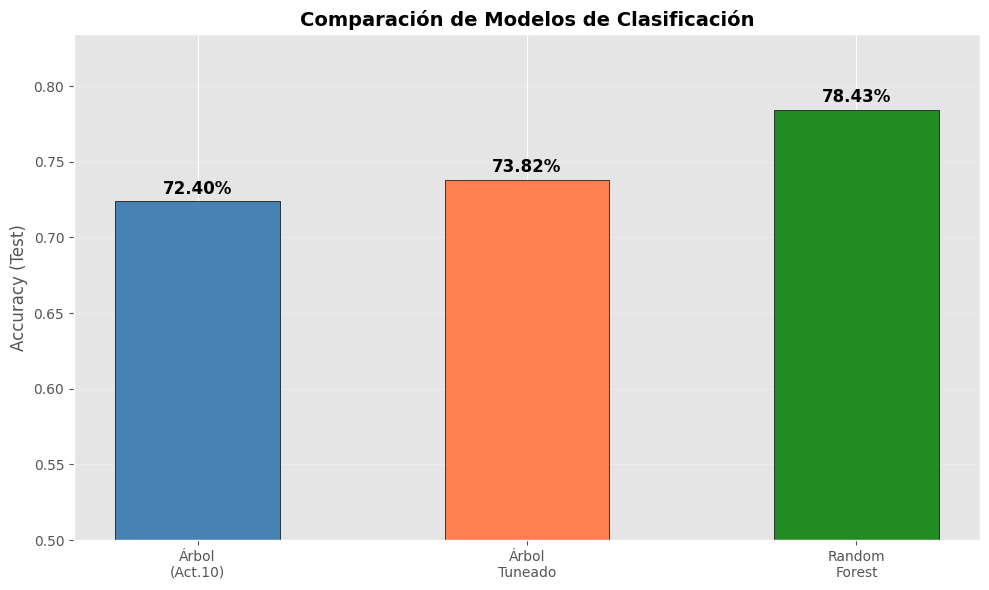


MEJOR MODELO: Random Forest con accuracy de 78.43%


In [51]:
### 15.3 Comparación final: Árbol vs Árbol Tuneado vs Random Forest

from sklearn.metrics import f1_score

print('=' * 80)
print('COMPARACIÓN FINAL DE MODELOS DE CLASIFICACIÓN')
print('=' * 80)
print()

print(f'{"Métrica":<25} {"Árbol (Act.10)":>18} {"Árbol Tuneado":>18} {"Random Forest":>18}')
print('-' * 82)
acc_tuned_train = grid_clf.best_estimator_.score(X_train_clf_subset, y_train_clf)
print(f'{"Accuracy Train":<25} {accuracy_score(y_train_clf, y_pred_train_clf):>17.4f} {acc_tuned_train:>17.4f} {acc_rf_train:>17.4f}')
print(f'{"Accuracy Test":<25} {acc_test:>17.4f} {acc_tuned:>17.4f} {acc_rf_test:>17.4f}')
print()

f1_base = f1_score(y_test_clf, y_pred_test_clf, labels=categories, average=None)
f1_tuned_vals = f1_score(y_test_clf, y_pred_tuned, labels=categories, average=None)
f1_rf = f1_score(y_test_clf, y_pred_rf_test, labels=categories, average=None)

print('F1-Score por clase:')
for i, cat in enumerate(categories):
    print(f'  {cat:<20} {f1_base[i]:>17.4f} {f1_tuned_vals[i]:>17.4f} {f1_rf[i]:>17.4f}')

f1_macro_base = f1_score(y_test_clf, y_pred_test_clf, labels=categories, average='macro')
f1_macro_tuned = f1_score(y_test_clf, y_pred_tuned, labels=categories, average='macro')
f1_macro_rf = f1_score(y_test_clf, y_pred_rf_test, labels=categories, average='macro')
print()
print(f'{"F1-Score Macro":<25} {f1_macro_base:>17.4f} {f1_macro_tuned:>17.4f} {f1_macro_rf:>17.4f}')

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(10, 6))
models = ['Árbol\n(Act.10)', 'Árbol\nTuneado', 'Random\nForest']
accs = [acc_test, acc_tuned, acc_rf_test]
colors = ['steelblue', 'coral', 'forestgreen']
bars = ax.bar(models, accs, color=colors, edgecolor='black', width=0.5)
ax.set_ylabel('Accuracy (Test)')
ax.set_title('Comparación de Modelos de Clasificación', fontweight='bold', fontsize=14)
ax.set_ylim(0.5, max(accs) + 0.05)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{100*acc:.2f}%', ha='center', fontweight='bold', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

best_idx = np.argmax(accs)
best_name = ['Árbol (Act.10)', 'Árbol Tuneado', 'Random Forest']
print(f'\nMEJOR MODELO: {best_name[best_idx]} con accuracy de {100*accs[best_idx]:.2f}%')

### Conclusiones

**Random Forest es el mejor modelo de clasificación**, alcanzando un accuracy de **78.43%** en test, superando al árbol tuneado (73.82%) y al árbol original (72.40%).

**Comparación de los tres modelos:**

| Modelo | Accuracy Test | F1 Macro | Mejor clase | Peor clase |
|---|---|---|---|---|
| Árbol (Act. 10) | 72.40% | 0.7099 | Intermedia (0.75) | Económica (0.67) |
| Árbol Tuneado | 73.82% | 0.7299 | Intermedia (0.76) | Económica (0.70) |
| **Random Forest** | **78.43%** | **0.7762** | **Intermedia (0.80)** | **Económica (0.75)** |

**¿Por qué Random Forest funciona mejor?**
- Al combinar 200 árboles, reduce la varianza de las predicciones. Un árbol individual puede equivocarse en casos difíciles, pero el consenso del bosque es más robusto.
- Cada árbol ve una muestra diferente de los datos (bootstrap) y un subconjunto de features, lo que hace que los errores de los árboles individuales no estén correlacionados.
- El F1-Score mejoró en las **tres categorías**, con la mayor ganancia en Económica (+0.08) y Cara (+0.07).

**Overfitting:** Random Forest tiene una diferencia de ~7 puntos entre train (85.76%) y test (78.43%), mayor que el árbol simple (~3 puntos). Sin embargo, lo que importa es el rendimiento absoluto en test, donde Random Forest gana por un margen significativo.

**Recomendación para SmartStay Advisors:** Usar Random Forest como modelo de clasificación de propiedades, ya que ofrece el mejor balance entre precisión y recall en todas las categorías de precio.